# Chapter 9 - Training and Adapting Vision-Language Models

## Learning Outcomes

By the end of this chapter, students should be able to:

1. **Explain the adaptation ladder for vision-language models (VLMs)** from zero-shot and few-shot prompting to RAG, supervised fine-tuning, parameter-efficient fine-tuning, preference optimization, and RL-based adaptation.

2. **Distinguish between methods that do not update model weights** (such as zero-shot, few-shot, and most RAG setups) and methods that do update model weights (such as SFT, LoRA, QLoRA, DPO, KTO, and RL-based methods).

3. **Explain how multimodal inputs are processed in a VLM pipeline**, including images, text prompts, processors, tokenization, and structured outputs.

4. **Describe how few-shot learning and RAG improve behavior without changing parameters**, and explain the intuition behind in-context learning and retrieval-based grounding.

5. **Define the supervised fine-tuning objective** and explain how SFT changes model behavior by increasing the likelihood of desired outputs.

6. **Explain LoRA and QLoRA**, including which layers are adapted, why low-rank updates are effective, and how quantization reduces memory and compute requirements.

7. **Construct and interpret preference-based training data** using prompt, chosen, and rejected responses for methods such as DPO.

8. **Explain the intuition and loss functions behind DPO, KTO, PPO, and RLOO**, and distinguish between offline preference optimization and online RL-based alignment.

9. **Describe the key reinforcement-learning concepts used in language-model alignment**, including policy, reward, return, advantage, baseline, KL regularization, and leave-one-out estimation.

10. **Evaluate the trade-offs among data requirements, compute cost, hardware constraints, and expected gains** when choosing an adaptation method for a real VLM case study.

## License

**Text, figures, and explanations:**  
© 2026 Imran Zualkernan. Licensed under **CC BY 4.0**.

**Code cells:**  
© 2026 Imran Zualkernan. Licensed under the **MIT License**.

You are free to reuse, modify, and redistribute with attribution.

## Overview

The chapter is organized according to the methods below. The opening sections load the dataset, choose a working subset, and define a common evaluation format so that the later method-by-method comparisons remain consistent.

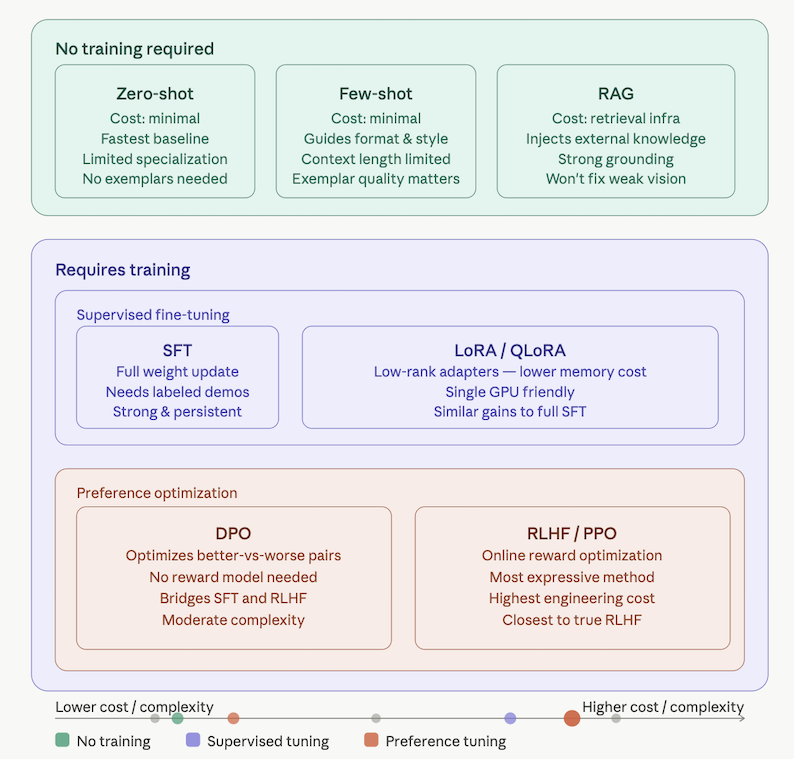

## Method table and budget ladder

This table defines the numbering used throughout the notebook.

| Method # | Method | Changes model weights? | Main cost | Typical use |
|---|---|---:|---|---|
| 1 | Zero-shot | No | almost free | get a baseline |
| 2 | Few-shot | No | low | format, style, and task steering |
| 3 | RAG | No | low to medium | inject external knowledge |
| 4 | SFT | Yes | medium | teach task behavior directly |
| 5 | LoRA / QLoRA | Yes, but only adapters | medium | practical specialization |
| 6 | DPO | Yes | medium to high | improve preference alignment |
| 7 | RLHF / PPO | Yes | highest | full online alignment pipeline |

A compact summary is:

- **Methods 1 and 2** change only the input prompt.
- **Method 3** changes the context supplied at inference time.
- **Methods 4 through 7** change the policy itself, meaning the conditional distribution $p_\theta(y \mid x, v)$.


## Environment setup

The next cells install and import the libraries used in the lecture-lab.

The main libraries are:

- `transformers` for loading the VLM,
- `datasets` for the rare-species dataset,
- `peft` for LoRA,
- `trl` for SFT and DPO trainers,
- `bitsandbytes` for 4-bit loading,
- `qwen-vl-utils` for multimodal processing helpers.

The Qwen model card notes that support for Qwen2.5-VL requires a sufficiently recent Transformers version. In practice, if an environment is stale, the safest fix is usually to update `transformers`, `accelerate`, `peft`, and `trl` together.


In [ ]:
import sys, os
import torch, numpy, scipy, sklearn, transformers

print("python:", sys.executable)
print("cwd:", os.getcwd())
print("torch:", torch.__version__)
print("numpy:", numpy.__version__)
print("scipy:", scipy.__version__)
print("sklearn:", sklearn.__version__)
print("transformers:", transformers.__version__)

print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))
    print("capability:", torch.cuda.get_device_capability(0))
    print("cuda runtime:", torch.version.cuda)

In [ ]:
import sys
import torch
import torchvision
import transformers

print("python:", sys.executable)
print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("transformers:", transformers.__version__)

In [ ]:

import os
import re
import json
import math
import random
from dataclasses import dataclass, asdict
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
from datasets import load_dataset, Dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score

from transformers import (
    AutoProcessor,
    BitsAndBytesConfig,
    Qwen2_5_VLForConditionalGeneration,
)
from qwen_vl_utils import process_vision_info


## Configuration

This cell defines the notebook configuration.

A few flags are intentionally set to `False` by default because some sections are heavier:

- `load_model_now`
- `run_field_guide_cache_build`
- `run_lora_training`
- `run_dpo_training`

A typical workflow is:

1. set `load_model_now = True`,
2. run the inference sections,
3. then enable `run_lora_training`,
4. then later enable `run_dpo_training` if desired.


In [ ]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

@dataclass
class LabConfig:
    model_name: str = "Qwen/Qwen2.5-VL-3B-Instruct"
    dataset_name: str = "imageomics/rare-species"
    dataset_split: str = "train"
    num_species: int = 8
    min_images_per_species: int = 25
    prompt_examples_per_species: int = 2
    train_per_species: int = 18
    val_per_species: int = 5
    test_per_species: int = 5
    eval_examples: int = 16
    assume_gpu: str = "single 5090-class GPU"
    use_4bit: bool = True
    load_model_now: bool = False

    # Retrieval / cache controls
    run_field_guide_cache_build: bool = False

    # SFT / DPO / RL stages
    run_lora_training: bool = False
    run_reward_model_training: bool = False
    run_dpo_training: bool = False
    run_rloo_training: bool = False

    # Online RL details
    use_vllm_for_rl: bool = False
    rloo_num_generations: int = 2
    rloo_max_completion_length: int = 160

    output_root: str = "outputs/qwen_rare_species"

cfg = LabConfig()
os.makedirs(cfg.output_root, exist_ok=True)
print(asdict(cfg))

In [ ]:
# Full pre-lecture run profile.
# Uncomment these lines if you want to run the expensive stages end to end.
#
cfg.run_field_guide_cache_build = False
cfg.run_lora_training = True
cfg.run_reward_model_training = True
cfg.run_dpo_training = True
cfg.run_rloo_training = True
cfg.use_vllm_for_rl = False   # keep False on a single GPU unless you have spare GPU(s)
print(asdict(cfg))

## Load the real Rare Species dataset

We load the real dataset from Hugging Face Datasets.

The goal is not to use the entire dataset for the lab. Instead, we want to:

- inspect its schema,
- verify the image and taxonomy fields,
- then carve out a smaller, biologically meaningful subset.

In [ ]:

raw_ds = load_dataset(cfg.dataset_name, split=cfg.dataset_split)
print(raw_ds)
print(raw_ds.features)


In [ ]:

if "image" not in raw_ds.column_names:
    raw_ds = raw_ds.rename_column("file_name", "image")

meta_cols = [c for c in raw_ds.column_names if c != "image"]
meta_df = pd.DataFrame(raw_ds.remove_columns("image"))
meta_df.head()


## Choose a biologically meaningful working subset

The original dataset is much larger than what we need for repeated experiments in one notebook. We therefore construct a subset that is:

- taxonomically coherent,
- large enough to be nontrivial,
- small enough to support repeated inference and tuning runs.

The next cell searches for a taxonomic branch with enough species and enough images per species. Using a coherent branch rather than a random grab-bag makes the downstream classification problem more realistic and also makes the RAG stage more meaningful because taxonomy and morphology become useful sources of context.

In [ ]:

def choose_taxonomic_branch(df, num_species=8, min_images_per_species=25):
    counts = df.groupby("sciName").size()
    valid_species = counts[counts >= min_images_per_species].index.tolist()
    work = df[df["sciName"].isin(valid_species)].copy()

    chosen_level, chosen_group = None, None
    for level in ["family", "order", "class", "phylum"]:
        stats = work.groupby(level)["sciName"].nunique().sort_values(ascending=False)
        viable = stats[stats >= num_species]
        if len(viable) > 0:
            chosen_level = level
            chosen_group = viable.index[0]
            break

    if chosen_level is None:
        chosen_level = "kingdom"
        chosen_group = "Animalia"

    branch_df = work[work[chosen_level] == chosen_group].copy()
    species_rank = branch_df.groupby("sciName").size().sort_values(ascending=False)
    chosen_species = species_rank.index[:num_species].tolist()
    branch_df = branch_df[branch_df["sciName"].isin(chosen_species)].copy()

    return chosen_level, chosen_group, chosen_species, branch_df

chosen_level, chosen_group, chosen_species, branch_df = choose_taxonomic_branch(
    meta_df,
    num_species=cfg.num_species,
    min_images_per_species=cfg.min_images_per_species,
)

print("Chosen taxonomic level:", chosen_level)
print("Chosen group:", chosen_group)
print("Chosen species:")
for s in chosen_species:
    print(" -", s)
print()
print(branch_df.groupby("sciName").size().sort_values(ascending=False))


In [ ]:

chosen_id_set = set(branch_df["rarespecies_id"].tolist())
lab_ds = raw_ds.filter(lambda ex: ex["rarespecies_id"] in chosen_id_set)

print(lab_ds)
print(pd.DataFrame(lab_ds.remove_columns("image")).groupby("sciName").size())


In [ ]:

def stratified_species_split(dataset, species_col="sciName", prompt_n=2, train_n=18, val_n=5, test_n=5, seed=42):
    df = pd.DataFrame(dataset.remove_columns("image"))
    rng = random.Random(seed)

    prompt_idx, train_idx, val_idx, test_idx = [], [], [], []

    for species_name, sub in df.groupby(species_col):
        idxs = list(sub.index)
        rng.shuffle(idxs)

        needed = prompt_n + train_n + val_n + test_n
        if len(idxs) < needed:
            raise ValueError(
                f"Species {species_name} has only {len(idxs)} examples but {needed} are needed. "
                "Reduce the split sizes or choose another subset."
            )

        prompt_idx.extend(idxs[:prompt_n])
        train_idx.extend(idxs[prompt_n:prompt_n + train_n])
        val_idx.extend(idxs[prompt_n + train_n:prompt_n + train_n + val_n])
        test_idx.extend(idxs[prompt_n + train_n + val_n:prompt_n + train_n + val_n + test_n])

    return (
        dataset.select(sorted(prompt_idx)),
        dataset.select(sorted(train_idx)),
        dataset.select(sorted(val_idx)),
        dataset.select(sorted(test_idx)),
    )

prompt_ds, train_ds, val_ds, test_ds = stratified_species_split(
    lab_ds,
    prompt_n=cfg.prompt_examples_per_species,
    train_n=cfg.train_per_species,
    val_n=cfg.val_per_species,
    test_n=cfg.test_per_species,
    seed=SEED,
)

print("prompt:", len(prompt_ds))
print("train :", len(train_ds))
print("val   :", len(val_ds))
print("test  :", len(test_ds))


In [ ]:

def show_species_grid(dataset, n_per_species=2, title=None, species_col="sciName"):
    df = pd.DataFrame(dataset.remove_columns("image"))
    chosen_indices = []
    for species_name, sub in df.groupby(species_col):
        chosen_indices.extend(list(sub.index[:n_per_species]))

    subset = dataset.select(chosen_indices)
    rows = int(math.ceil(len(subset) / 4))
    fig, axes = plt.subplots(rows, 4, figsize=(16, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, ex in zip(axes, subset):
        ax.imshow(ex["image"])
        ax.set_title(f"{ex['sciName']}\n({ex['common']})", fontsize=9)
        ax.axis("off")

    for ax in axes[len(subset):]:
        ax.axis("off")

    if title:
        fig.suptitle(title, fontsize=15)
    plt.tight_layout()
    plt.show()

show_species_grid(prompt_ds, n_per_species=2, title="Prompt / exemplars split: two images per chosen species")


## Load the Qwen VLM

We use `Qwen/Qwen2.5-VL-3B-Instruct` throughout.

### Why load in 4-bit?

A 4-bit load makes it practical to keep a strong base model in memory while reserving room for adapters, optimizer state, and batches on a single high-end GPU. This is also the standard setup behind QLoRA: a quantized frozen base model plus trainable low-rank adapters.

In [ ]:

def load_qwen_vl(model_name, use_4bit=True):
    model_kwargs = {"device_map": "auto"}

    if use_4bit and torch.cuda.is_available():
        compute_dtype = torch.bfloat16 if torch.cuda.is_available() else torch.float32
        quant_cfg = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_use_double_quant=True,
            bnb_4bit_compute_dtype=compute_dtype,
        )
        model_kwargs["quantization_config"] = quant_cfg
        model_kwargs["torch_dtype"] = compute_dtype
    else:
        model_kwargs["torch_dtype"] = "auto"

    model = Qwen2_5_VLForConditionalGeneration.from_pretrained(model_name, **model_kwargs)
    processor = AutoProcessor.from_pretrained(model_name)
    return model, processor

cfg.load_model_now = True # Set to True to load the model immediately, or False to skip loading for now.

model, processor = None, None
if cfg.load_model_now:
    model, processor = load_qwen_vl(cfg.model_name, use_4bit=cfg.use_4bit)
    print("Model loaded.")
else:
    print("Set cfg.load_model_now = True and rerun this cell when ready to load the VLM.")


## Shared utility functions

The next cell defines reusable utilities for:

1. creating a consistent task prompt,
2. calling the model,
3. parsing structured outputs,
4. evaluating predictions under the same format.

Keeping the task definition and output format fixed is important because later comparisons should reflect the method itself rather than a hidden change in prompt wording or evaluation logic.


In [ ]:

SYSTEM_PROMPT = (
    "You are a careful biodiversity vision-language assistant. "
    "You should classify the animal image only among the candidate species provided by the user. "
    "Be cautious, use visible evidence, and avoid overclaiming."
)

def candidate_block(candidate_species):
    return "\n".join([f"- {name}" for name in candidate_species])

def format_gold_answer(example):
    return (
        f"scientific_name: {example['sciName']}\n"
        f"common_name: {example['common']}\n"
        f"family: {example['family']}\n"
        f"genus: {example['genus']}\n"
        f"confidence: 1.00\n"
        f"evidence: The label is given by the dataset annotation for this image."
    )

def make_user_prompt(candidate_species, extra_context=None):
    prompt = f"""
Classify the animal in the image into exactly one of the following candidate species:

{candidate_block(candidate_species)}

Return exactly in the following format:

scientific_name: <one candidate exactly>
common_name: <common name if known or 'unknown'>
family: <family if known or 'unknown'>
confidence: <number from 0.00 to 1.00>
evidence: <one or two short sentences based on visible evidence>

Important rules:
1. The scientific name must be one of the candidate species exactly.
2. If uncertain, still choose the closest candidate but lower the confidence.
3. Do not invent species outside the candidate set.
""".strip()

    if extra_context is not None and len(str(extra_context).strip()) > 0:
        prompt += "\n\nAdditional retrieved context:\n" + str(extra_context).strip()

    return prompt

def render_messages(messages):
    prompt_text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )
    image_inputs, video_inputs = process_vision_info(messages)
    return prompt_text, image_inputs, video_inputs

def generate_from_messages(messages, max_new_tokens=180, do_sample=False, temperature=0.0):
    if model is None or processor is None:
        raise RuntimeError("Load the model first by setting cfg.load_model_now = True and rerunning the model cell.")

    prompt_text, image_inputs, video_inputs = render_messages(messages)
    inputs = processor(
        text=[prompt_text],
        images=image_inputs,
        videos=video_inputs,
        return_tensors="pt",
    )

    device = next(model.parameters()).device
    inputs = {k: v.to(device) if hasattr(v, "to") else v for k, v in inputs.items()}

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=do_sample,
            temperature=temperature,
        )

    generated_ids = output_ids[:, inputs["input_ids"].shape[1]:]
    text = processor.batch_decode(
        generated_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )[0]
    return text

def make_single_query_messages(example, candidate_species, extra_context=None):
    return [
        {"role": "system", "content": [{"type": "text", "text": SYSTEM_PROMPT}]},
        {
            "role": "user",
            "content": [
                {"type": "image", "image": example["image"]},
                {"type": "text", "text": make_user_prompt(candidate_species, extra_context=extra_context)},
            ],
        },
    ]

def normalize_text(x):
    return re.sub(r"\s+", " ", str(x).strip().lower())

def extract_scientific_name(output_text, candidate_species):
    m = re.search(r"scientific_name\s*:\s*(.+)", output_text, flags=re.IGNORECASE)
    if m:
        raw = normalize_text(m.group(1))
        for c in candidate_species:
            if normalize_text(c) == raw:
                return c

    lowered = normalize_text(output_text)
    for c in candidate_species:
        if normalize_text(c) in lowered:
            return c

    return None


# Mathematical setup for the common VLM policy

Before comparing methods, write the model once in a form that all later sections can reuse.

A modern autoregressive vision-language model defines a conditional distribution

$$
p_\theta(y \mid x, v) = \prod_{t=1}^{T} p_\theta(y_t \mid y_{<t}, x, v).
$$

Variable meanings:

- $x$: the text prompt, instruction, or textual context.
- $v$: the visual input after image preprocessing and conversion into visual tokens or visual features.
- $y = (y_1, y_2, \dots, y_T)$: the output token sequence produced by the model.
- $y_t$: the token generated at step $t$.
- $y_{<t}$: all previously generated tokens before step $t$.
- $T$: the output length in tokens.
- $\theta$: the trainable parameters of the VLM.

This factorization says that the model reads the prompt and image, then predicts the response one token at a time.

## What changes across methods?

- **Methods 1 and 2:** keep $\theta$ fixed and modify the context.
- **Method 3:** keep $\theta$ fixed and augment the context with retrieved evidence.
- **Methods 4 through 7:** update some or all trainable parameters.

Throughout this lecture, the rare-species task uses the same basic input-output structure. What changes is the mechanism by which the model is adapted.


# Method — Zero-shot prompting

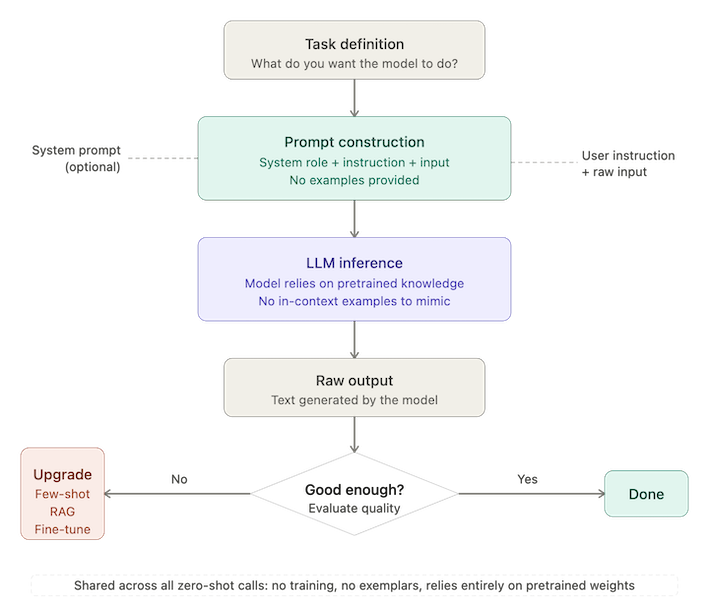

## Idea

In zero-shot prompting we do **not** change the model parameters and we do **not** add retrieved external knowledge. We present the pretrained VLM with an image and an instruction and ask it to solve the task directly.

For this lecture, the task is rare-species recognition and structured reporting. The model sees an organism image and is asked to produce a species prediction together with taxonomic evidence.

This is the cheapest point on the adaptation ladder:

- no gradient updates,
- no optimizer,
- no task-specific training set,
- no vector index.

It is therefore the baseline for every later method.

## Mathematical view

Let the text instruction be $x$, let the image be $v$, and let the generated answer be $y = (y_1, \dots, y_T)$. The VLM defines

$$
p_\theta(y \mid x, v) = \prod_{t=1}^{T} p_\theta(y_t \mid y_{<t}, x, v).
$$

Variable meanings:

- $x$: the textual instruction.
- $v$: the image.
- $y$: the whole generated answer.
- $y_t$: the token predicted at generation step $t$.
- $y_{<t}$: the prefix already generated before step $t$.
- $T$: answer length.
- $\theta$: the pretrained model parameters.

A deterministic decoding rule often approximates the most likely answer:

$$
\hat{y} \approx \arg\max_y p_\theta(y \mid x, v).
$$

The important point is that the parameters are fixed during adaptation. **We do not run an update such as**

$$
\theta \leftarrow \theta - \eta \nabla_\theta \mathcal{L}.
$$

So zero-shot adaptation changes the **question** being asked, not the underlying model.

## Why does it work?

Zero-shot works because the pretrained VLM has already learned broad visual and textual regularities during large-scale pretraining and instruction tuning. If the current task is close to that prior experience, a well-written prompt may be enough.

But zero-shot is limited by what the model already knows. It cannot acquire new task-specific distinctions from the current notebook alone.

## Code Summary

The next cells do three things:

1. build a single multimodal prompt for one rare-species example,
2. run the Qwen VLM without any weight updates,
3. evaluate the same prompt pattern over a small held-out subset.

That gives us a clean baseline before we move to stronger but more expensive methods.


In [ ]:

candidate_species = sorted(set(pd.DataFrame(test_ds.remove_columns("image"))["sciName"].tolist()))
example = test_ds[0]

messages = make_single_query_messages(example, candidate_species)
zero_shot_output = generate_from_messages(messages)
print(zero_shot_output)
print("\nPredicted scientific name:", extract_scientific_name(zero_shot_output, candidate_species))
print("Ground truth:", example["sciName"])


In [ ]:

def evaluate_method(dataset, predict_fn, candidate_species, limit=16):
    truths, preds, rows = [], [], []
    subset = dataset.select(range(min(limit, len(dataset))))

    for ex in subset:
        pred_text = predict_fn(ex)
        pred_label = extract_scientific_name(pred_text, candidate_species)
        truths.append(ex["sciName"])
        preds.append(pred_label if pred_label is not None else "__NONE__")
        rows.append(
            {
                "truth": ex["sciName"],
                "pred": pred_label,
                "raw_output": pred_text[:400],
            }
        )

    acc = accuracy_score(truths, preds)
    return acc, pd.DataFrame(rows)

zero_shot_predict = lambda ex: generate_from_messages(make_single_query_messages(ex, candidate_species))
zero_shot_acc, zero_shot_details = evaluate_method(
    test_ds,
    zero_shot_predict,
    candidate_species,
    limit=cfg.eval_examples,
)
print("Zero-shot accuracy:", round(zero_shot_acc, 4))
zero_shot_details.head()


## Issues with Zero-Shot

### Prompt sensitivity

Because the parameters are fixed, the result can change noticeably when we alter wording, output format, or the amount of label guidance in the prompt.

### No new knowledge

If the model does not already know the relevant species distinctions, zero-shot prompting cannot inject them.

### Weak calibration

The model may produce a species name confidently even when the image is ambiguous or when the species lies outside the working subset.

### Fine-grained recognition is hard

Rare-species classification is difficult because two species can differ only in subtle texture, morphology, or context cues.

## Key references for Zero-Shot Learning

- [Brown et al., *Language Models are Few-Shot Learners* (2020)](https://arxiv.org/abs/2005.14165)
- [Radford et al., *Learning Transferable Visual Models From Natural Language Supervision* (2021)](https://arxiv.org/abs/2103.00020)
- [Qwen2.5-VL-3B-Instruct model card](https://huggingface.co/Qwen/Qwen2.5-VL-3B-Instruct)


# Method -  Few-shot / in-context learning
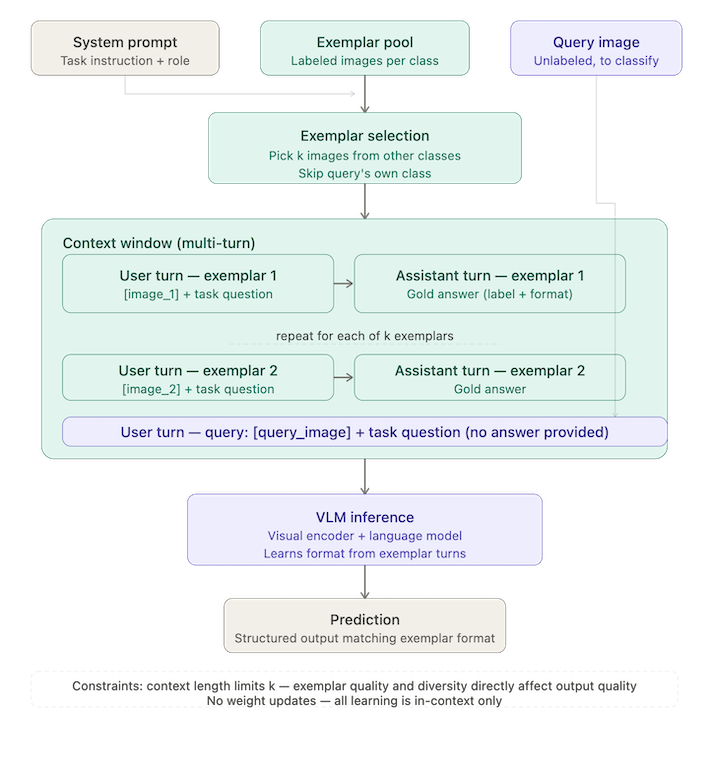
## Idea

Few-shot prompting keeps the **model weights fixed**, but it adds a small number of **worked examples inside the context window**. These examples show the model what kind of answer we want.

For our rare-species task, the few-shot examples demonstrate the desired structured output:

- scientific name,
- common name,
- family,
- genus,
- confidence,
- evidence.

The goal is **not** to change the parameters by gradient descent. The goal is to change the *conditioning information* that enters the forward pass.

## Mathematical view

Let the demonstration set inserted into the prompt be

$$
\mathcal{D}_{\mathrm{ctx}} = \{(x_j, v_j, y_j)\}_{j=1}^{m}.
$$

Here:

- $m$ is the number of demonstrations.
- $x_j$ is the instruction text in demonstration $j$.
- $v_j$ is the image in demonstration $j$.
- $y_j$ is the worked answer in demonstration $j$.

For a new query $(x, v)$, the model defines

$$
p_\theta(y \mid x, v, \mathcal{D}_{\mathrm{ctx}}).
$$

The autoregressive factorization is still

$$
p_\theta(y \mid x, v, \mathcal{D}_{\mathrm{ctx}})
=
\prod_{t=1}^{T}
p_\theta(y_t \mid y_{<t}, x, v, \mathcal{D}_{\mathrm{ctx}}).
$$

Here:

- $y = (y_1, \dots, y_T)$ is the answer sequence for the new query.
- $y_t$ is the token generated at step $t$.
- $y_{<t}$ is the previously generated prefix.
- $\theta$ is still the original frozen pretrained parameter set.

There is **no** optimizer update such as

$$
\theta \leftarrow \theta - \eta \nabla_\theta \mathcal{L}.
$$

## Why can few-shot learning work if $\theta$ does not change?

This is the central conceptual question.

The short answer is: **the context changes even though the weights do not**.

A transformer computes hidden states by attending over the full prompt. When we insert demonstrations, we change:

- the tokens that are present,
- the key/value memories available to later tokens,
- the attention scores between query tokens and demonstration tokens,
- and therefore the hidden-state trajectory that leads to the output logits.

So the model can behave differently even though $\theta$ is unchanged.

A useful way to say this mathematically is:

$$
h_t = f_\theta(h_{<t}, x, v, \mathcal{D}_{\mathrm{ctx}}),
$$

where $h_t$ is the hidden representation used to predict token $y_t$. Since $\mathcal{D}_{\mathrm{ctx}}$ changes, the hidden state $h_t$ changes. That changes the logits, and therefore the final answer.

## Why does it potentially work?

Few-shot prompting can work for at least four reasons.

### Format induction

If every example uses the same output schema, the model infers that the new answer should follow that same schema.

### Task disambiguation

A short user prompt may be ambiguous. Demonstrations tell the model what we *mean* by the task.

For example, "identify this animal" could mean:

- give a common name,
- give a scientific name,
- provide a ranked list,
- describe uncertainty,
- explain visible evidence.

A few examples resolve that ambiguity.

### Label-space restriction

When the examples repeatedly show the same candidate set and style, the model is nudged toward a specific subtask over that candidate space.

### Implicit Bayesian-style adaptation

One can think informally of the model as using the demonstrations to infer a latent task description and then solving the new query under that inferred task. No gradient descent occurs, but the forward pass behaves like a temporary task adaptation.

## What few-shot learning is *not*

Few-shot prompting is not:

- gradient-based learning on the new examples,
- permanent storage of those examples in the weights,
- guaranteed generalization beyond the current context window.

Once the prompt disappears, the adaptation disappears.

## Why can it fail?

Few-shot prompting can fail because:

- the demonstrations are poorly chosen,
- the examples are too long and crowd the context window,
- the model matches superficial patterns rather than the intended task,
- or the task requires information the model never learned during pretraining.

## Code Summary

The code below chooses exemplars from the prompt split, inserts them into the prompt, and queries the same Qwen VLM. The only thing that changes relative to zero-shot prompting is the context.

## Issues

- Context is **expensive**: every extra example consumes tokens and, for VLMs, image processing budget.
- Demonstration order matters.
- A demonstration can help one class but hurt another if it is visually confusing.
- Unlike SFT, few-shot prompting does not create a reusable adapted model.

## References for Few Shot learning

- Brown, T. B., Mann, B., Ryder, N., et al.  
  [*Language Models are Few-Shot Learners*](https://arxiv.org/abs/2005.14165)

- Min, S., Lyu, X., Holtzman, A., et al.  
  [*Rethinking the Role of Demonstrations: What Makes In-Context Learning Work?*](https://arxiv.org/abs/2202.12837)

- Xie, S. M., Raghunathan, A., Liang, P., Ma, T.  
  [*An Explanation of In-context Learning as Implicit Bayesian Inference*](https://arxiv.org/abs/2111.02080)

- Lv, S.-L., Chen, Y.-Y., Zhou, Z., Yang, M., Guo, L.-Z.  
  [*BMIP: Bi-directional Modality Interaction Prompt Learning for VLM*](https://www.ijcai.org/proceedings/2025/655)

In [ ]:

# Build a pool of exemplars for each species from the prompt_ds, which we will use for few-shot prompting.
def exemplar_pool_by_species(dataset):
    pool = defaultdict(list)
    for ex in dataset:
        pool[ex["sciName"]].append(ex)
    return pool

# We will use the prompt_ds as our exemplar pool for few-shot prompting. In a more advanced setup, we could have a 
# larger external pool and retrieve from it based on similarity to the query.

prompt_pool = exemplar_pool_by_species(prompt_ds)

# For simplicity, this exemplar selection just takes the first k examples from the prompt pool for each candidate species 
# (skipping the query's true species). A more advanced version could use a learned retriever or similarity-based selection.
def choose_exemplars_for_query(query_example, candidate_species, k=2):
    exemplars = []
    for species_name in candidate_species:
        if species_name == query_example["sciName"]:
            continue
        if len(prompt_pool[species_name]) > 0:
            exemplars.append(prompt_pool[species_name][0])
        if len(exemplars) >= k:
            break
    return exemplars

# Now we can construct few-shot messages by interleaving the chosen exemplars with their gold answers, followed by the query.
# For example, if k=2 and we have 4 candidate species, we might take 2 exemplars from 2 of the non-query species, 
# format them with their gold answers, and then add the query at the end. The system prompt remains the same.
# gold answer is means the label provided by the dataset annotation for the exemplar image, which we include in 
# the assistant's response to show the model what a correct answer looks like for those exemplars.

def make_few_shot_messages(query_example, candidate_species, k=2):
    messages = [{"role": "system", "content": [{"type": "text", "text": SYSTEM_PROMPT}]}]
    exemplars = choose_exemplars_for_query(query_example, candidate_species, k=k)

    for ex in exemplars:
        messages.append(
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": ex["image"]},
                    {"type": "text", "text": make_user_prompt(candidate_species)},
                ],
            }
        )
        messages.append(
            {
                "role": "assistant",
                "content": [{"type": "text", "text": format_gold_answer(ex)}],
            }
        )

    messages.append(
        {
            "role": "user",
            "content": [
                {"type": "image", "image": query_example["image"]},
                {"type": "text", "text": make_user_prompt(candidate_species)},
            ],
        }
    )
    return messages

few_shot_output = generate_from_messages(make_few_shot_messages(test_ds[0], candidate_species, k=2))
print(few_shot_output)


In [ ]:
# Define a function to make few-shot predictions for each example in the test dataset. 
# We will then evaluate the accuracy of these predictions against the ground truth labels.

few_shot_predict = lambda ex: generate_from_messages(make_few_shot_messages(ex, candidate_species, k=2))
few_shot_acc, few_shot_details = evaluate_method(
    test_ds,
    few_shot_predict,
    candidate_species,
    limit=cfg.eval_examples,
)
print("Few-shot accuracy:", round(few_shot_acc, 4))
few_shot_details.head()

## Issues With Few-Shot Learning

### Context-window cost

Each demonstration **consumes tokens**, and multimodal examples are **expensive** in both memory and latency.

### Example selection matters

Poor or **unrepresentative** demonstrations can hurt performance. In fine-grained species tasks, support examples should ideally resemble the target style and label granularity.

### No persistent learning

Once the context is removed, the adaptation disappears. Few-shot prompting does not produce a reusable trained model.

### Susceptibility to ordering effects

The order of examples can matter. This is a reminder that in-context learning is still an inference-time phenomenon rather than an explicit optimizer-based training procedure.

## Key references

- [Brown et al., *Language Models are Few-Shot Learners* (2020)](https://arxiv.org/abs/2005.14165)
- [Min et al., *Rethinking the Role of Demonstrations: What Makes In-Context Learning Work?* (2022)](https://arxiv.org/abs/2202.12837)
- [Dong et al., *A Survey on In-Context Learning* (2023)](https://arxiv.org/abs/2301.00234)


# Method - Retrieval-Augmented Generation (RAG)

## Simple RAG 
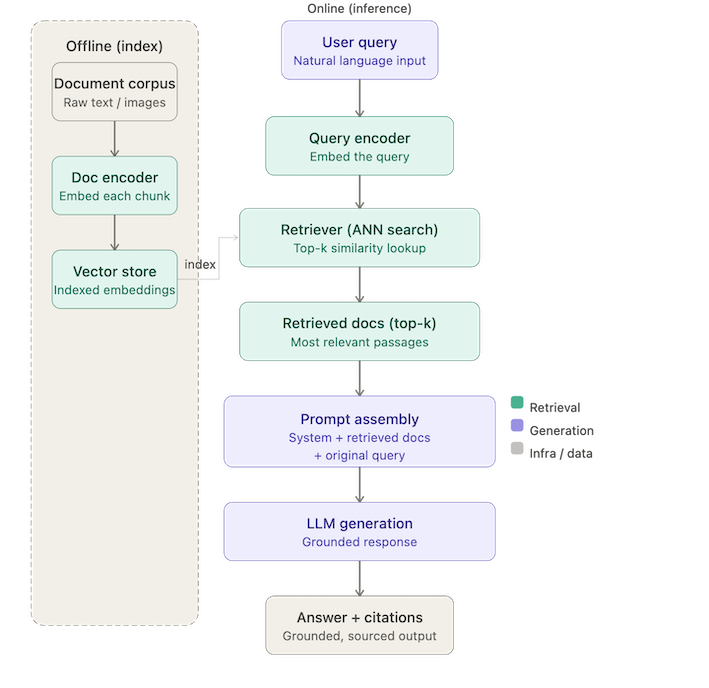

## RAG with Backpropagation 
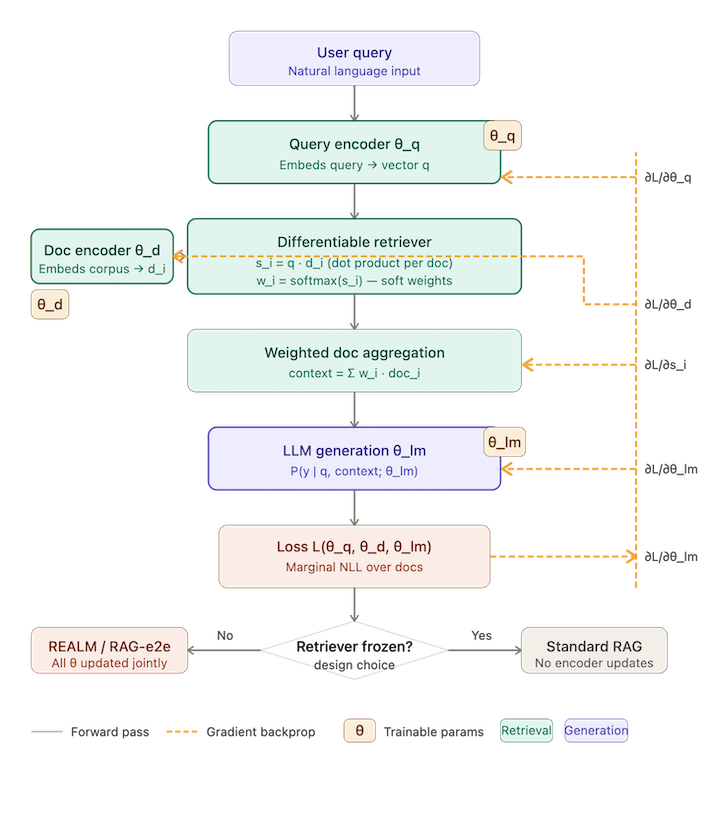

## Idea

RAG augments the model with an **external memory**. Instead of relying only on pretrained parameters or only on in-context demonstrations, we retrieve relevant documents and place them into the generation context.

For the rare-species task, the retrieved documents are **species cards** derived from real metadata. They can contain:

- scientific and common names,
- taxonomic hierarchy,
- short descriptive notes,
- comparison cues against nearby species.

Conceptually, RAG separates two roles:

- the **retriever** decides which evidence to bring in,
- the **generator** decides how to answer using that evidence.

## Basic probabilistic picture

Let:

- $x$ be the text instruction,
- $v$ be the image,
- $q(x, v)$ be the query representation produced from the instruction and image,
- $z$ be one retrieved document,
- $\mathcal{Z}$ be the document collection,
- $\eta$ be the retriever parameters,
- $\theta$ be the generator parameters,
- $y = (y_1, \dots, y_T)$ be the output sequence.

A standard latent-document RAG model writes

$$
p_{\theta,\eta}(y \mid x, v)
=
\sum_{z \in \mathcal{Z}}
p_\eta(z \mid q(x, v))
\,
p_\theta(y \mid x, v, z).
$$

This equation means:

1. the retriever assigns a probability to each document through $p_\eta(z \mid q(x, v))$,
2. the generator assigns an answer likelihood conditioned on one document through $p_\theta(y \mid x, v, z)$,
3. the final answer probability is a mixture over documents.

In practice, we use only the top-$k$ retrieved documents:

$$
p_{\theta,\eta}(y \mid x, v)
\approx
\sum_{z \in \mathrm{TopK}(q(x,v), k)}
p_\eta(z \mid q(x, v))
\,
p_\theta(y \mid x, v, z).
$$

The generator itself remains autoregressive:

$$
p_\theta(y \mid x, v, z)
=
\prod_{t=1}^{T}
p_\theta(y_t \mid y_{<t}, x, v, z).
$$

Here:

- $y_t$ is token $t$,
- $y_{<t}$ is the prefix before step $t$,
- $T$ is the answer length.

## 3. What is the gold target in RAG?

At **training time**, the gold target is usually the desired answer sequence

$$
y^* = (y_1^*, \dots, y_T^*).
$$

For our notebook, $y^*$ is the structured rare-species answer we want the model to produce, such as the correct scientific name, family, genus, and a short evidence sentence.

We care about $y^*$ because RAG training tries to increase

$$
p_{\theta,\eta}(y^* \mid x, v),
$$

not just produce any fluent answer. The gold target tells the system which retrieved evidence was actually useful for producing the desired answer.

At **inference time**, there is no gold answer. We retrieve documents and generate a response directly.

## Marginal log-likelihood and why the equations jump

The quantity actually optimized in a differentiable RAG formulation is often the log marginal likelihood of the gold answer:

$$
\mathcal{L}_{\mathrm{RAG}}(\theta,\eta)
=
- \log p_{\theta,\eta}(y^* \mid x, v).
$$

Using the latent-document expansion, this becomes

$$
\mathcal{L}_{\mathrm{RAG}}(\theta,\eta)
=
-
\log
\left[
\sum_{z \in \mathcal{Z}}
p_\eta(z \mid q(x, v))
\,
p_\theta(y^* \mid x, v, z)
\right].
$$

So the "jump" is simply this:

1. define the answer probability as a latent-variable mixture over documents,
2. plug the gold answer $y^*$ into that mixture,
3. take the negative log to get the training loss.

Nothing mysterious is happening. It is just maximum likelihood with a latent retrieved document.

## Posterior responsibility weights $w(z)$

A very useful quantity is

$$
w(z)
=
\frac{
p_\eta(z \mid q(x,v))
\,
p_\theta(y^* \mid x, v, z)
}{
\sum_{z' \in \mathcal{Z}}
p_\eta(z' \mid q(x,v))
\,
p_\theta(y^* \mid x, v, z')
}.
$$

This is a posterior responsibility weight.

Here:

- the numerator says how plausible document $z$ was *before* seeing the target and how well it explains the target,
- the denominator normalizes across all candidate documents.

So $w(z)$ answers the question:

> **After seeing the gold answer, how much responsibility should document $z$ receive for explaining it?**

Intuitively:

- if a document was highly retrieved and also made the gold answer very likely, $w(z)$ is large,
- if a document was retrieved but did not help explain the gold answer, $w(z)$ is small.

This is why $w(z)$ is so important. It tells us which documents were actually useful, not just which documents were initially retrieved.

## Gradient with respect to the generator

Start from

$$
\log p_{\theta,\eta}(y^* \mid x, v)
=
\log
\left[
\sum_{z}
p_\eta(z \mid q(x,v))
\,
p_\theta(y^* \mid x, v, z)
\right].
$$

Differentiate with respect to $\theta$:

$$
\nabla_\theta
\log p_{\theta,\eta}(y^* \mid x, v)
=
\sum_{z}
w(z)
\,
\nabla_\theta
\log p_\theta(y^* \mid x, v, z).
$$

This says the generator update is a weighted average of per-document generator gradients.

Interpretation:

- if a document strongly supports the gold answer, it gets a large weight,
- the model learns more strongly from that document-conditioned path.

## Gradient with respect to the retriever

Similarly, the retriever gradient is

$$
\nabla_\eta
\log p_{\theta,\eta}(y^* \mid x, v)
=
\sum_{z}
w(z)
\,
\nabla_\eta
\log p_\eta(z \mid q(x,v)).
$$

So the retriever is pushed to assign more mass to documents that, in hindsight, explain the gold answer well.

This is the cleanest way to understand end-to-end differentiable RAG:

- the generator learns to use documents better,
- the retriever learns to fetch documents that better support the gold target.

## Why this matters even if we use a frozen retriever

In our example implementation, we use a lightweight **TF-IDF** retriever and do **not** backpropagate through retrieval. That is common in real systems because it is simpler and cheaper.

But the math above still matters because it explains the ideal joint-learning picture:

- classic production RAG often uses frozen retrieval,
- fully differentiable RAG tries to learn both retrieval and generation together.

## Token-level intuition

Another way to understand RAG is at the token level.

Without retrieval, the next-token distribution is

$$
p_\theta(y_t \mid y_{<t}, x, v).
$$

With retrieval, the model instead uses

$$
p_{\theta,\eta}(y_t \mid y_{<t}, x, v)
\approx
\sum_{z \in \mathrm{TopK}}
p_\eta(z \mid q(x,v))
\,
p_\theta(y_t \mid y_{<t}, x, v, z).
$$

So retrieval changes the logits indirectly by changing the context used to compute them.

## Code Summary

The code below constructs species cards from the real metadata, builds a simple vector-space retriever, retrieves top-$k$ cards for each query image, and appends those cards to the prompt before generation.

## Issues

- Retrieval quality matters as much as generator quality.
- More retrieved text is not always better; irrelevant context can hurt generation.
- In frozen-index RAG, the retriever does not learn from downstream failures.
- Retrieval can introduce false confidence if the retrieved evidence is wrong or noisy.

## References

- Lewis, P., Perez, E., Piktus, A., et al.  
  [*Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks*](https://arxiv.org/abs/2005.11401)

- Karpukhin, V., Oguz, B., Min, S., et al.  
  [*Dense Passage Retrieval for Open-Domain Question Answering*](https://arxiv.org/abs/2004.04906)

- Hsia, J., Shaikh, A., Wang, Z., Neubig, G.  
  [*RAGGED: Towards Informed Design of Retrieval-Augmented Generation Systems*](https://openreview.net/forum?id=KDXj60FpJr)

- Xu, S., Pang, L., Shen, H., Cheng, X.  
  [*A Theory for Token-Level Harmonization in Retrieval-Augmented Generation*](https://openreview.net/forum?id=tbx3u2oZAu)

- Ma, S., Xu, C., Jiang, X., et al.  
  [*Think-on-Graph 2.0: Deep and Faithful Large Language Model Reasoning with Knowledge-guided Retrieval-Augmented Generation*](https://openreview.net/forum?id=oFBu7qaZpS)

In [ ]:
# In simple RAG setups, we might want to build plain text "species cards" for each candidate species that summarize key 
# information about them.

def build_plain_species_cards(dataset):
    cards = {}
    df = pd.DataFrame(dataset.remove_columns("image"))
    grouped = df.groupby("sciName").first().reset_index()

    for _, row in grouped.iterrows():
        cards[row["sciName"]] = (
            f"Scientific name: {row['sciName']}\n"
            f"Common name: {row['common']}\n"
            f"Kingdom: {row['kingdom']}\n"
            f"Phylum: {row['phylum']}\n"
            f"Class: {row['class']}\n"
            f"Order: {row['order']}\n"
            f"Family: {row['family']}\n"
            f"Genus: {row['genus']}\n"
            f"Species: {row['species']}\n"
        )
    return cards

species_cards = build_plain_species_cards(train_ds)
species_cards


In [ ]:
# We can also try to build more visual field-guide style cards that highlight key visual traits and confusions, 
# using the RAG prompting approach with the exemplar images.

FIELD_GUIDE_CACHE = os.path.join(cfg.output_root, "species_field_guide_cards.json")

def build_visual_field_guide_cards(prompt_dataset, cache_path=FIELD_GUIDE_CACHE, max_imgs_per_species=2):
    if os.path.exists(cache_path):
        with open(cache_path, "r", encoding="utf-8") as f:
            return json.load(f)

    if model is None or processor is None:
        raise RuntimeError("Load the model first before building visual field-guide cards.")

    pool = exemplar_pool_by_species(prompt_dataset)
    cards = {}

    for species_name, examples in pool.items():
        exs = examples[:max_imgs_per_species]
        shared_user_text = """
You are writing a concise field-guide note for a single species using the example images.
Do not guess habitat or behavior unless it is visible.
Write:
1. recurring visible traits,
2. likely visual confusions,
3. a short practical note for a classifier.
Keep it under 120 words.
""".strip()

        user_content = [{"type": "image", "image": ex["image"]} for ex in exs]
        user_content.append({"type": "text", "text": shared_user_text})

        messages = [
            {"role": "system", "content": [{"type": "text", "text": "You are a careful biodiversity assistant."}]},
            {"role": "user", "content": user_content},
        ]
        text = generate_from_messages(messages, max_new_tokens=160, do_sample=False)
        cards[species_name] = text

    with open(cache_path, "w", encoding="utf-8") as f:
        json.dump(cards, f, ensure_ascii=False, indent=2)

    return cards

if cfg.run_field_guide_cache_build:
    visual_cards = build_visual_field_guide_cards(prompt_ds)
elif os.path.exists(FIELD_GUIDE_CACHE):
    with open(FIELD_GUIDE_CACHE, "r", encoding="utf-8") as f:
        visual_cards = json.load(f)
else:
    visual_cards = {}

merged_cards = {}
for k, v in species_cards.items():
    merged_cards[k] = v + ("\nVisual note:\n" + visual_cards.get(k, "") if k in visual_cards else "")

merged_cards[list(merged_cards.keys())[0]]


In [ ]:
# For RAG we have both the plain text cards and the visual exemplar-based cards. We can vectorize these and retrieve based on the query,
# or we could directly use the exemplar-based cards as few-shot context without explicit retrieval. 
# Here we demonstrate a simple TF-IDF based retrieval over the merged cards, which could be used to augment the prompt for each query.

card_texts = list(merged_cards.values())
card_species = list(merged_cards.keys())

# We use a simple TF-IDF vectorizer for demonstration, but in a more advanced setup we could use a learned retriever 
# or a more powerful embedding model.

vectorizer = TfidfVectorizer(stop_words="english", ngram_range=(1, 2))
doc_matrix = vectorizer.fit_transform(card_texts)

# k=3 means we retrieve the top 3 most relevant species cards based on the query text, which could then be i
# ncluded in the prompt for the VLM to provide additional context for classification.

def retrieve_species_cards(query_text, k=3):
    q = vectorizer.transform([query_text])
    scores = (doc_matrix @ q.T).toarray().reshape(-1)
    top_idx = np.argsort(-scores)[:k]
    return [(card_species[i], card_texts[i], float(scores[i])) for i in top_idx]

def describe_image_for_retrieval(example):
    messages = [
        {"role": "system", "content": [{"type": "text", "text": "You are a careful biodiversity assistant."}]},
        {
            "role": "user",
            "content": [
                {"type": "image", "image": example["image"]},
                {
                    "type": "text",
                    "text": (
                        "Describe only the visible morphology of the animal in 4 short bullet points. "
                        "Do not guess the species name."
                    ),
                },
            ],
        },
    ]
    return generate_from_messages(messages, max_new_tokens=100, do_sample=False)


In [ ]:
# Example of retrieving relevant species cards based on a query text, which could be the user prompt for a test example.

query_example = test_ds[0]
query_description = describe_image_for_retrieval(query_example)
retrieved = retrieve_species_cards(query_description, k=3)

print("Query description:\n")
print(query_description)
print("\nRetrieved cards:\n")
for sp, doc, score in retrieved:
    print("=" * 80)
    print(sp, "| score =", round(score, 4))
    print(doc[:700])


In [ ]:
# Now we can build a RAG-style context block for the query by including the retrieved card information, which 
# can then be appended to the user prompt for the VLM. This allows the model to use the retrieved information 
# as additional context when making its classification decision.    

def rag_context_for_example(example, top_k=3):
    query_description = describe_image_for_retrieval(example)
    retrieved = retrieve_species_cards(query_description, k=top_k)

    context_blocks = [f"Image description query:\n{query_description}\n"]
    for rank, (species_name, doc, score) in enumerate(retrieved, start=1):
        context_blocks.append(
            f"[Retrieved card {rank}] score={score:.4f}\nCandidate species: {species_name}\n{doc}"
        )
    return "\n\n".join(context_blocks)

rag_context = rag_context_for_example(test_ds[0], top_k=3)
rag_output = generate_from_messages(make_single_query_messages(test_ds[0], candidate_species, extra_context=rag_context))
print(rag_output)


In [ ]:
# Finally, we can evaluate the RAG-augmented predictions across the test set to see if the retrieval context improves
# accuracy compared to zero-shot and few-shot prompting alone.  

def rag_predict(ex):
    extra_context = rag_context_for_example(ex, top_k=3)
    return generate_from_messages(make_single_query_messages(ex, candidate_species, extra_context=extra_context))

# Note: Depending on the size of the test set and the complexity of the model, this RAG evaluation may take some time 
# to run, especially if the retrieval step is computationally intensive. Adjust the limit parameter 
# in evaluate_method as needed for quicker testing.

rag_acc, rag_details = evaluate_method(
    test_ds,
    rag_predict,
    candidate_species,
    limit=min(8, cfg.eval_examples),
)
print("RAG accuracy:", round(rag_acc, 4))
rag_details.head()


## Issues with RAG

### Retrieval quality is a bottleneck

If the correct species card is not retrieved, the generator cannot use it.

### Retrieval errors can be amplified

A confident but wrong retrieved document can steer the model toward a persuasive incorrect answer.

### Frozen retrieval is not end-to-end learning

In practical ANN- or TF-IDF-based pipelines, the retrieval stage is often non-differentiable and fixed. That makes engineering easier, but it also means the retriever itself does not improve during notebook training.

### Long contexts increase cost

As we retrieve more species cards, latency and memory rise, and the model may become distracted by irrelevant evidence.

## Key references

- [Lewis et al., *Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks* (2020)](https://arxiv.org/abs/2005.11401)
- [Karpukhin et al., *Dense Passage Retrieval for Open-Domain Question Answering* (2020)](https://arxiv.org/abs/2004.04906)
- [Gao et al., *Retrieval-Augmented Generation for Large Language Models: A Survey* (2023)](https://arxiv.org/abs/2312.10997)


# Method — Supervised fine-tuning (SFT)

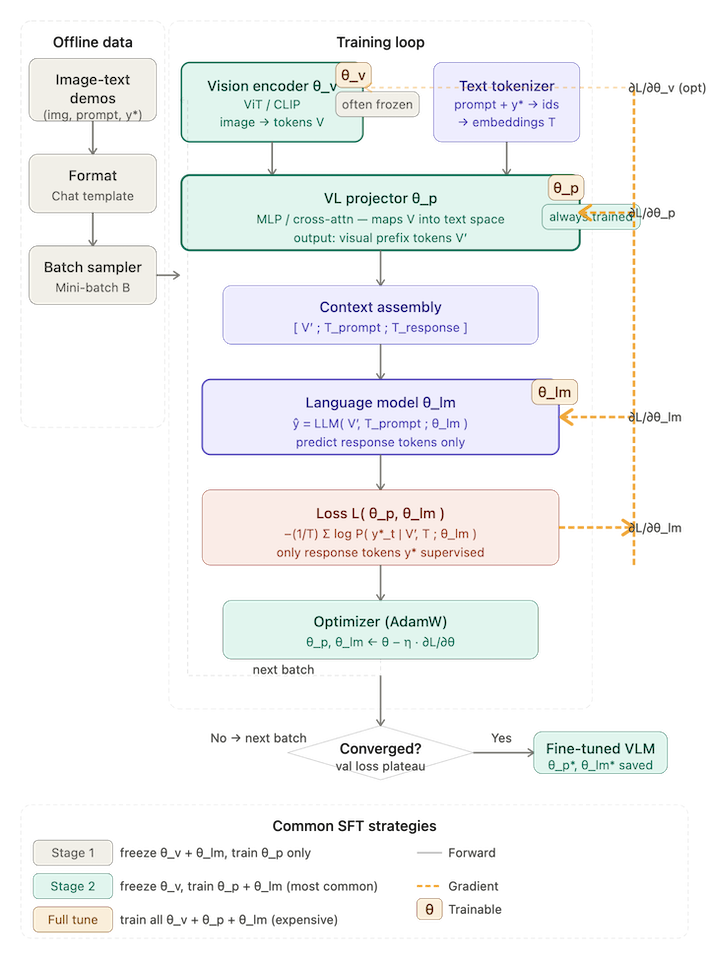

## Idea

Supervised fine-tuning moves from inference-time adaptation to **parameter learning**. We now provide labeled image-instruction-answer triples and update the model so that the desired answer becomes more likely not only in one prompt, but across the task distribution.

For the rare-species task, each training example contains:

- an image,
- an instruction asking for structured species identification,
- a target answer containing taxonomic fields and evidence text.

This is the standard post-training entry point for turning a general VLM into a domain-adapted assistant.

## Mathematical view

Let the supervised dataset be

$$
\mathcal{D}
=
\{(x_i, v_i, y_i^*)\}_{i=1}^{N}.
$$

Here:

- $N$ is the number of training examples,
- $x_i$ is the instruction for example $i$,
- $v_i$ is the image for example $i$,
- $y_i^* = (y_{i,1}^*, \dots, y_{i,T_i}^*)$ is the target output sequence,
- $T_i$ is the target length for example $i$.

The model factorizes the target probability as

$$
p_\theta(y_i^* \mid x_i, v_i)
=
\prod_{t=1}^{T_i}
p_\theta(y_{i,t}^* \mid y_{i,<t}^*, x_i, v_i).
$$

The standard causal-language-model objective is the negative log-likelihood

$$
\mathcal{L}_{\mathrm{SFT}}(\theta)
=
-
\sum_{i=1}^{N}
\sum_{t=1}^{T_i}
\log p_\theta(y_{i,t}^* \mid y_{i,<t}^*, x_i, v_i).
$$

If we use a loss mask $m_{i,t} \in \{0,1\}$ to decide which tokens count, then

$$
\mathcal{L}_{\mathrm{SFT}}(\theta)
=
-
\sum_{i=1}^{N}
\sum_{t=1}^{T_i}
m_{i,t}
\log p_\theta(y_{i,t}^* \mid y_{i,<t}^*, x_i, v_i).
$$

Here:

- $m_{i,t} = 1$ means token $t$ contributes to the loss,
- $m_{i,t} = 0$ means token $t$ is ignored.

## Intuition behind the loss

At each position, the model predicts a distribution over the next token. The cross-entropy loss simply says:

> the correct token should receive higher probability than it currently does.

So SFT repeatedly performs the update:

- show the model the image and prompt,
- compare the model's next-token distribution to the desired next token,
- increase the probability of the desired token,
- repeat over all target tokens and all examples.

This is still maximum likelihood. The difference from zero-shot and few-shot prompting is that the adaptation is now stored in the parameters.

## Can SFT be related to a score?

Yes, but we must be careful about what "score" means.

In diffusion models, "score" usually means $\nabla_x \log p(x)$, which is a gradient with respect to the **input**.

In SFT for language models, the relevant quantity is instead the gradient with respect to the **parameters**:

$$
\nabla_\theta \log p_\theta(y_i^* \mid x_i, v_i).
$$

This is sometimes informally called a parameter-score term. The SFT update follows

$$
\nabla_\theta \log p_\theta(y_i^* \mid x_i, v_i)
=
\sum_{t=1}^{T_i}
\nabla_\theta
\log p_\theta(y_{i,t}^* \mid y_{i,<t}^*, x_i, v_i).
$$

So SFT adds together next-token parameter-score contributions across the sequence.

Intuitively, every correct token says:

> "move the parameters in the direction that would have made me more probable."

## What is an assistant token?

In chat-style training, the tokenized conversation contains:

- system-role text,  **prompt system component**
- user-role text,    **prompt role component**
- assistant-role text, **The reply from the system**
- plus special control markers used by the chat template.

When practitioners say **assistant tokens**, they usually do **not** mean one special vocabulary token. They mean the **span of tokens that belong to the assistant's reply**.

So an assistant token mask is a binary sequence such as

$$
a_{i,t} \in \{0,1\},
$$

where:

- $a_{i,t} = 1$ means token position $t$ belongs to the assistant span,
- $a_{i,t} = 0$ means it belongs to the system or user span, or is padding.

Then an assistant-only loss can be written as

$$
\mathcal{L}_{\mathrm{assistant}}(\theta)
=
-
\sum_{i=1}^{N}
\sum_{t=1}^{T_i}
a_{i,t}
\log p_\theta(y_{i,t}^* \mid y_{i,<t}^*, x_i, v_i).
$$

The reason this is useful is simple: in instruction tuning we usually want the model to learn **how to answer**, not to waste capacity learning to imitate the **system** or **user** prompts that were already given.

## Important practical note for Qwen2.5-VL

The `assistant_only_loss=True` path in TRL depends on the tokenizer or processor being able to return an assistant-token mask. Hugging Face documents that this mask is only available for chat templates that support `{% generation %}` blocks. Qwen2.5-VL community discussion reports that the default chat template can return an all-zero assistant mask, so this path may require a custom template or a manual masking strategy.

That is why the runnable code below keeps the SFT path simple and robust instead of forcing assistant-only masking.

## Code Summary

The code constructs a conversational VLM training dataset with one image and one structured assistant answer per example, then applies *LoRA-based* SFT on Qwen2.5-VL.

## Data structure and label masking

The code uses a conversational representation because the processor knows how to place the image markers correctly for the model. During training, the causal objective uses a one-token shift, and padding positions are ignored.

If you later enable assistant-only masking with a compatible chat template, the same core objective still applies; you simply change which token positions are counted.

## Issues

- SFT needs labeled target outputs.
- If the target answers are noisy, the model learns that noise.
- SFT may overfit format and phrasing if the dataset is too small or too homogeneous.
- With VLMs, truncation is dangerous because it can remove image tokens or visual placeholders.

## References for SFT

- Ouyang, L., Wu, J., Jiang, X., et al.  
  [*Training Language Models to Follow Instructions with Human Feedback*](https://arxiv.org/abs/2203.02155)

- Hugging Face TRL documentation.  
  [*SFT Trainer*](https://huggingface.co/docs/trl/en/sft_trainer)

- Hugging Face Transformers documentation.  
  [*Tokenizer.apply_chat_template and assistant token masks*](https://huggingface.co/docs/transformers/main_classes/tokenizer)

- Qwen2.5-VL community discussion.  
  [*Chat template of AutoTokenizer does not work on assistant mask tokens*](https://huggingface.co/Qwen/Qwen2.5-VL-3B-Instruct/discussions/27)

## Build the supervised dataset

The code below converts our rare-species examples into a standard message format suitable for instruction-style multimodal training.

This is conceptually important because a lot of modern post-training work is really about **dataset formatting**. The same underlying image and label can be turned into:

- a plain classification dataset,
- an instruction-following dataset,
- a rationale dataset,
- a preference dataset.

That is why dataset design is often as important as optimizer design.


In [ ]:

def make_sft_dataset(source_ds, candidate_species):
    rows = []
    for ex in source_ds:
        rows.append(
            {
                "image": ex["image"],
                "messages": [
                    {"role": "system", "content": [{"type": "text", "text": SYSTEM_PROMPT}]},
                    {
                        "role": "user",
                        "content": [
                            {"type": "image"},
                            {"type": "text", "text": make_user_prompt(candidate_species)},
                        ],
                    },
                    {
                        "role": "assistant",
                        "content": [{"type": "text", "text": format_gold_answer(ex)}],
                    },
                ],
                "sciName": ex["sciName"],
            }
        )
    return Dataset.from_list(rows)

sft_train_ds = make_sft_dataset(train_ds, candidate_species)
sft_val_ds = make_sft_dataset(val_ds, candidate_species)

sft_train_ds[0]


## Data structure, assistant spans, and label masking

For each example, we build a conversation with:

1. a system message,
2. a user message containing the image and instruction,
3. an assistant message containing the desired structured answer.

From the model's point of view, only the assistant response should be predicted. That is why many instruction-tuning pipelines conceptually implement a label mask.

Let

$$
m_{i,t} \in \{0,1\}
$$

be the loss mask for token position $t$ in example $i$.

Then:

- $m_{i,t} = 1$ means token $t$ contributes to the loss,
- $m_{i,t} = 0$ means token $t$ is context only.

If we specifically want to keep only assistant tokens, we can write the mask as

$$
a_{i,t} \in \{0,1\},
$$

where:

- $a_{i,t} = 1$ means token $t$ belongs to the assistant span,
- $a_{i,t} = 0$ means it belongs to system text, user text, or padding.

In many codebases the phrase **assistant token** refers to these assistant-span positions, not to one special token in the vocabulary.

The image itself is not a text token. Instead, it is inserted structurally in the conversation representation and converted by the processor into visual tensors expected by the VLM. The decoder then predicts assistant tokens conditioned on both:

- the textual conversation prefix,
- the visual representation of the image.

This is the bridge between ordinary language-model cross-entropy and multimodal instruction tuning.

## Issues with SFT

### Label quality dominates performance

If the target answers are noisy, inconsistent, or partially wrong, the model will learn those inconsistencies.

### Mode collapse toward one answer style

SFT encourages imitation of the provided targets. If all targets have the same wording, the model may become overly rigid.

### Catastrophic forgetting is possible

If fine-tuning is too aggressive or too narrow, the model can lose some of its broader pretrained capabilities.

### Data imbalance matters

In rare-species settings, some species may dominate the working subset. Without care, the model may learn biased priors.

## 10. Key references

- [Ouyang et al., *Training Language Models to Follow Instructions with Human Feedback* (2022)](https://arxiv.org/abs/2203.02155)
- [TRL SFTTrainer documentation](https://huggingface.co/docs/trl/en/sft_trainer)
- [Transformers tokenizer documentation on assistant-token masks](https://huggingface.co/docs/transformers/main_classes/tokenizer)
- [Qwen2.5-VL-3B-Instruct model card](https://huggingface.co/Qwen/Qwen2.5-VL-3B-Instruct)

# Approach — LoRA / QLoRA 

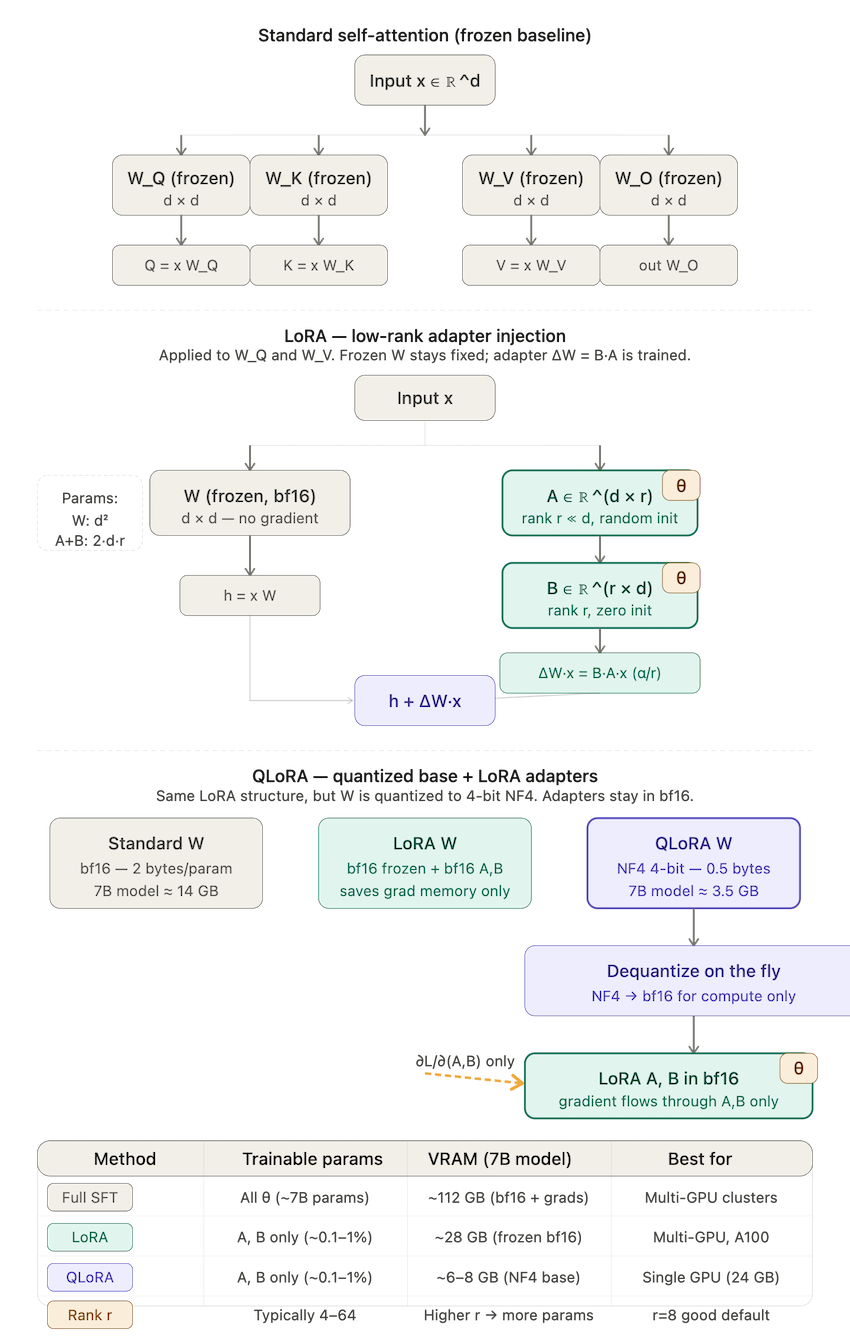

## Idea

LoRA stands for **Low-Rank Adaptation**. It does not change the supervised objective. Instead, it changes **which parameters are trainable** and **how the update is represented**.

The motivation is that full fine-tuning of a modern VLM is **expensive** in memory, optimizer state, and checkpoint size. LoRA addresses this by freezing the original pretrained weights and learning a low-rank update only for selected linear layers.

QLoRA pushes the idea further by storing the frozen base model in **low-bit quantized form** while still training the adapter parameters in higher precision.

## Base layer mathematics

Suppose a linear layer uses weight matrix

$$
W \in \mathbb{R}^{d_{\mathrm{out}} \times d_{\mathrm{in}}}
$$

and applies it to an input vector

$$
x \in \mathbb{R}^{d_{\mathrm{in}}}.
$$

Its output is

$$
h = Wx,
$$

where $h \in \mathbb{R}^{d_{\mathrm{out}}}$.

In full fine-tuning, every entry of $W$ is updated. In LoRA, we keep $W$ frozen and instead define

$$
W' = W + \Delta W,
$$

with

$$
\Delta W = \frac{\alpha}{r} B A,
$$

where

$$
A \in \mathbb{R}^{r \times d_{\mathrm{in}}},
\qquad
B \in \mathbb{R}^{d_{\mathrm{out}} \times r}.
$$

Here:

- $d_{\mathrm{in}}$ is the input width of the layer,
- $d_{\mathrm{out}}$ is the output width of the layer,
- $r$ is the LoRA rank,
- $\alpha$ is the LoRA scaling factor,
- $A$ and $B$ are trainable low-rank matrices,
- $\Delta W$ is the learned additive update.

The trainable parameter count becomes

$$
r d_{\mathrm{in}} + d_{\mathrm{out}} r,
$$

which is much smaller than the full count

$$
d_{\mathrm{out}} d_{\mathrm{in}}
$$

when $r \ll \min(d_{\mathrm{in}}, d_{\mathrm{out}})$.

## Why a low-rank update can work

A downstream task rarely needs to rewrite every degree of freedom in every large matrix. Many useful task adaptations can be represented as a structured directional correction to the original weight.

LoRA assumes that the required downstream correction is approximately low-rank. This is an empirical modeling assumption, and in practice it often works surprisingly well.

## Which layers are actually adapted in a transformer VLM?

In this notebook we target the following linear sublayers:

- `q_proj`
- `k_proj`
- `v_proj`
- `o_proj`
- `gate_proj`
- `up_proj`
- `down_proj`

These correspond to two major subsystems.

### Attention projections

For one attention block, let:

- $X \in \mathbb{R}^{L \times d}$ be the input hidden states,
- $L$ be the sequence length,
- $d$ be the model width.

The projections are

$$
Q = X W_Q,
\qquad
K = X W_K,
\qquad
V = X W_V.
$$

Here:

- $W_Q$ is the query projection matrix (`q_proj`),
- $W_K$ is the key projection matrix (`k_proj`),
- $W_V$ is the value projection matrix (`v_proj`).

The attention output is

$$
\mathrm{Attn}(X)
=
\mathrm{softmax}
\left(
\frac{QK^\top}{\sqrt{d_h}}
\right)
V,
$$

where $d_h$ is the head dimension.

Then the result is projected back through

$$
\mathrm{AttnOut}(X) = \mathrm{Attn}(X) W_O,
$$

where $W_O$ is the output projection matrix (`o_proj`).

#### Why adapt these layers?

Because they control:

- what each token asks for through $Q$,
- what content is available through $K$ and $V$,
- how the attended information is mixed back into the residual stream through $W_O$.

If the downstream task requires new visual-semantic associations, adapting the attention projections is one of the most direct ways to change information routing.

### MLP projections

A transformer block also contains an MLP, often of the form

$$
\mathrm{MLP}(x)
=
W_{\mathrm{down}}
\,
\phi\!\left(
W_{\mathrm{gate}} x
\right)
\odot
\left(
W_{\mathrm{up}} x
\right),
$$

for a SwiGLU-style block. In practice the exact layout can vary, but conceptually:

- `gate_proj` computes gating features,
- `up_proj` expands features to a higher-dimensional intermediate space,
- `down_proj` projects back to the model width.

#### Why adapt these layers?

Because attention determines **where information flows**, while the MLP determines **how that information is transformed** after it arrives.

So:

- adapting `q_proj`, `k_proj`, `v_proj`, `o_proj` changes routing and cross-token interaction,
- adapting `gate_proj`, `up_proj`, `down_proj` changes local nonlinear feature transformation.

This is why the common practical recipe is to adapt both families.

## What changes in QLoRA?

QLoRA leaves the LoRA idea intact but stores the frozen base model in quantized form, typically 4-bit, while the LoRA adapters remain trainable in higher precision.

So conceptually:

- the base model stays frozen and compressed,
- the optimizer only updates the adapter weights,
- backpropagation still flows through the forward pass, but only adapter parameters receive updates.

## The loss optimized in LoRA / QLoRA

LoRA does **not** invent a new task loss. For supervised tuning it still optimizes

$$
\mathcal{L}_{\mathrm{SFT}}(\theta_{\mathrm{base}}, A, B)
=
-
\sum_{i,t}
m_{i,t}
\log p(y_{i,t}^* \mid y_{i,<t}^*, x_i, v_i).
$$

The difference is that the base model weights are frozen and only the adapter parameters change. If we denote the trainable parameters collectively by $\psi = \{A,B\}$, then the actual update is

$$
\psi \leftarrow \psi - \eta \nabla_\psi \mathcal{L}_{\mathrm{SFT}}.
$$

The frozen base weights are not updated.

## Intuition behind the LoRA loss

The loss is still telling the model to increase the probability of the correct next token. The only restriction is *where the model is allowed to change*. LoRA says:

> you may not move the full matrix $W$, but you may add a structured low-rank correction $\Delta W$.

That makes optimization cheaper and often more stable on limited hardware.

## Code Summary

The code below builds a LoRA configuration for Qwen2.5-VL, attaches adapters to the selected projection layers, and trains only those adapters with the same supervised objective as SFT.

## Issues

- If the rank $r$ is too small, the adapter may be too weak.
- If the target modules are too narrow, the model may not adapt enough.
- If too many target modules are adapted, LoRA becomes heavier and can approach full fine-tuning costs.
- QLoRA reduces memory but can still be sensitive to optimizer settings and sequence length.

## References

- Hu, E. J., Shen, Y., Wallis, P., et al.  
  [*LoRA: Low-Rank Adaptation of Large Language Models*](https://arxiv.org/abs/2106.09685)

- Dettmers, T., Pagnoni, A., Holtzman, A., Zettlemoyer, L.  
  [*QLoRA: Efficient Finetuning of Quantized LLMs*](https://arxiv.org/abs/2305.14314)

- Hugging Face PEFT documentation.  
  [*LoRA reference*](https://huggingface.co/docs/peft/en/package_reference/lora)

In [ ]:
#  Now we have the sft_train_ds and sft_val_ds prepared with the messages and images formatted for supervised fine-tuning. 
# We can proceed to set up the LoRA training configuration and trainer using the PEFT and TRL
# Peft stands for Parameter-Efficient Fine-Tuning, which allows us to fine-tune only a small subset of the model's parameters 
# (the LoRA adapters) while keeping the rest of the model frozen.
# TRL stands for Transformer Reinforcement Learning, which provides utilities for training language models with various objectives,
# ncluding supervised fine-tuning (SFT), direct preference optimization (DPO), and reinforcement learning with human feedback (RLHF).


from peft import LoraConfig, prepare_model_for_kbit_training, PeftModel
from trl import SFTConfig, SFTTrainer

# target_modules specifies which parts of the model we want to apply LoRA adapters to. 
# For a causal language model, we typically target the projection layers in the attention mechanism (q_proj, k_proj, v_proj, o_proj) 
# and the feedforward network (gate_proj, up_proj, down_proj). This allows the LoRA adapters to effectively modulate 
# the key components of the model's computation while keeping the rest of the parameters frozen.

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
)

sft_output_dir = os.path.join(cfg.output_root, "qwen_rare_species_lora")

sft_args = SFTConfig(
    output_dir=sft_output_dir,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,
    num_train_epochs=1,
    learning_rate=2e-4,
    logging_steps=5,
    eval_strategy="steps",
    eval_steps=20,
    save_steps=50,
    save_total_limit=2,
    remove_unused_columns=False,
    max_length=None,
    bf16=torch.cuda.is_available(),
    gradient_checkpointing=True,
    report_to="none",
)

print(lora_config)
print(sft_args)


## Inspecting target modules

The next code cell verifies that suffixes such as `q_proj`, `v_proj`, and `down_proj` really occur inside the loaded model. This is important because LoRA acts on concrete named modules, not on abstract equations.


In [ ]:

if model is None:
    print("Load the model first to inspect concrete module names.")
else:
    target_suffixes = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]
    matches = [name for name, _ in model.named_modules() if any(name.endswith(s) for s in target_suffixes)]
    print(f"Found {len(matches)} matching modules.")
    for name in matches[:60]:
        print(name)
    if len(matches) > 60:
        print("... (truncated)")


## The loss optimized in LoRA / QLoRA

LoRA does **not** introduce a new task loss. The supervised objective is still cross-entropy on the assistant tokens,

$$
\mathcal{L}_{\mathrm{SFT}}(\theta')
=
-
\sum_{(x,v,y^*)}
\sum_t
\log p_{\theta'}(y_t^* \mid y_{<t}^*, x, v),
$$

but the parameterization changes from a dense update to a low-rank one.

This means:

- **SFT** answers the question: what should the model learn?
- **LoRA** answers the question: which parameters are allowed to move, and in what form?

That separation is pedagogically important because it clarifies why LoRA and SFT are not competing ideas. LoRA is a parameter-efficient way to implement SFT.


In [ ]:

# QLoRA-style VLM fine-tuning
# Set cfg.run_lora_training = True before running.

# The SFTTrainer from TRL will handle the supervised fine-tuning loop, applying the LoRA adapters to the specified target modules in the model.


if cfg.run_lora_training:
    train_model, train_processor = load_qwen_vl(cfg.model_name, use_4bit=cfg.use_4bit)
    train_model.config.use_cache = False
    train_model = prepare_model_for_kbit_training(train_model)

    sft_trainer = SFTTrainer(
        model=train_model,
        args=sft_args,
        train_dataset=sft_train_ds,
        eval_dataset=sft_val_ds,
        processing_class=train_processor,
        peft_config=lora_config,
    )

    sft_trainer.train()
    sft_trainer.save_model(sft_output_dir)
    train_processor.save_pretrained(sft_output_dir)
    print(f"Saved LoRA adapter to {sft_output_dir}")
else:
    print("Set cfg.run_lora_training = True to run LoRA/QLoRA training.")


## Evaluation and interpretation

The evaluation stage uses the same species-identification task as the earlier methods. That keeps the comparison fair: we are changing the adaptation method, not secretly changing the task.

When the LoRA adapter works well, we expect improvements in:

- label consistency,
- structured formatting,
- taxonomic grounding,
- robustness across repeated examples from the same working subset.


In [ ]:
# After training, we can load the base model and apply the trained LoRA adapters to get the adapted model for evaluation.

def load_base_plus_adapter(base_model_name, adapter_dir, use_4bit=True):
    base_model, proc = load_qwen_vl(base_model_name, use_4bit=use_4bit)
    adapted = PeftModel.from_pretrained(base_model, adapter_dir)
    adapted.eval()
    return adapted, proc

adapted_model, adapted_processor = None, None
if os.path.exists(sft_output_dir):
    adapted_model, adapted_processor = load_base_plus_adapter(cfg.model_name, sft_output_dir, use_4bit=cfg.use_4bit)
    print("Loaded adapted model from adapter directory.")
else:
    print("Adapter directory not found yet. Train first, or skip this section for now.")


In [ ]:

# We can now evaluate the LoRA-adapted model using the same evaluation function we defined earlier, 
# which will use the generate_with_explicit_model function to make predictions with the adapted model.  
# This allows us to see how much the LoRA fine-tuning has improved the model's accuracy on the test set
#  compared to the zero-shot and few-shot baselines.  

def generate_with_explicit_model(curr_model, curr_processor, messages, max_new_tokens=180):
    prompt_text = curr_processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )
    image_inputs, video_inputs = process_vision_info(messages)

    inputs = curr_processor(
        text=[prompt_text],
        images=image_inputs,
        videos=video_inputs,
        return_tensors="pt",
    )

   # Move inputs to the same device as the model (important for 4-bit models which may be on GPU while the main process is on CPU). 
    device = next(curr_model.parameters()).device

   # Ensure all tensor inputs are moved to the correct device, while non-tensor inputs are left as is.  ``
    inputs = {k: v.to(device) if hasattr(v, "to") else v for k, v in inputs.items()}

    # Generate output using the adapted model without tracking gradients (inference mode).
    # **inputs unpacks the dictionary of inputs into keyword arguments for the generate function,
    # which allows us to use the same input preparation logic as before but with the adapted model.

    with torch.no_grad():
        output_ids = curr_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
        )

    # The generated output_ids will include the input prompt tokens followed by the newly generated tokens.
    # We slice the output_ids to get only the generated part by skipping the length of the input 
    # prompt tokens (inputs["input_ids"].shape[1]). This gives us the tokens that were  
    # generated in response to the prompt, which we then decode into text using the processor's batch_decode method.
    
    generated_ids = output_ids[:, inputs["input_ids"].shape[1]:]
    text = curr_processor.batch_decode(
        generated_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )[0]
    return text

def lora_predict(ex):
    messages = make_single_query_messages(ex, candidate_species)
    return generate_with_explicit_model(adapted_model, adapted_processor, messages)

if adapted_model is not None:
    lora_acc, lora_details = evaluate_method(
        test_ds,
        lora_predict,
        candidate_species,
        limit=cfg.eval_examples,
    )
    print("LoRA-adapted accuracy:", round(lora_acc, 4))
    lora_details.head()
else:
    print("No adapted model loaded yet.")


## Issues with LoRA

### Rank $r$ is a real modeling choice

If $r$ is too small, the adapter may not have enough capacity. If it is too large, some of the memory and regularization benefits disappear.

### Target-module choice changes behavior

Adapting only attention projections is cheaper. Adding the MLP projections usually increases capacity, but also increases trainable parameters and the risk of overfitting.

### Quantization is an approximation

QLoRA is extremely useful in practice, but quantization still changes the numerical behavior of the frozen base model.

### Fine-grained biology can overfit

On rare-species subsets, the model may latch onto background, photographer style, or context artifacts rather than true morphology if the data are not curated carefully.

## 10. Key references

- [Hu et al., *LoRA: Low-Rank Adaptation of Large Language Models* (2021)](https://arxiv.org/abs/2106.09685)
- [Dettmers et al., *QLoRA: Efficient Finetuning of Quantized LLMs* (2023)](https://arxiv.org/abs/2305.14314)
- [PEFT LoRA documentation](https://huggingface.co/docs/peft/package_reference/lora)


# Background — Reinforcement learning Primer

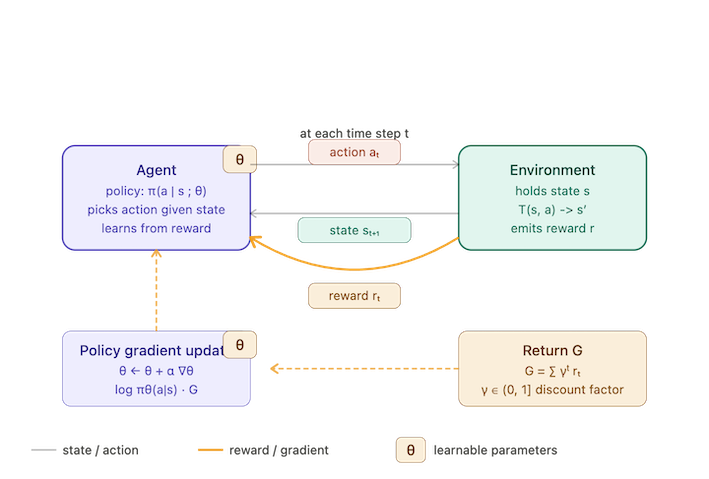

## Idea

In reinforcement learning, a policy interacts with an environment, receives rewards, and is updated so that higher-reward behavior becomes more likely.

## Basic objects

An episodic reinforcement-learning problem uses:

- $s_t$: state at time step $t$,
- $a_t$: action at time step $t$,
- $r_t$: reward observed after that action,
- $\pi_\theta(a_t \mid s_t)$: the policy distribution.

For sequence generation:

- the state $s_t$ is the prompt, image, and generated prefix available at step $t$,
- the action $a_t$ is the next generated token,
- the policy $\pi_\theta$ is the language model or vision-language model.

## Return and objective

With discount factor $\gamma \in [0,1]$, the return from time $t$ is

$$
G_t = \sum_{k=t}^{T} \gamma^{k-t} r_k.
$$

Here:

- $G_t$ is the total discounted future reward starting at time $t$,
- $\gamma$ controls how much future rewards are discounted,
- $T$ is the terminal step.

The policy objective is

$$
J(\theta) = \mathbb{E}_{\tau \sim \pi_\theta}[R(\tau)],
$$

where:

- $\tau$ is a sampled trajectory,
- $R(\tau)$ is the total reward of that trajectory.

### What is $R(\tau)$?

In this notation, $R(\tau)$ means the **total reward of the whole trajectory** $\tau$.

A trajectory is a full rollout of states, actions, and rewards, for example:

$$
\tau = (s_0, a_0, r_0, s_1, a_1, r_1, \dots, s_T).
$$

There are two related quantities:

- $r_k$ = the **immediate reward** received at step $k$
- $R(\tau)$ = the **total cumulative reward** over the entire trajectory

A common definition is:

$$
R(\tau) = \sum_{t=0}^{T} \gamma^t r_t.
$$

So $R(\tau)$ is the discounted sum of all rewards along the trajectory.

This is closely related to $G_t$, which is the return starting from time $t$:

$$
G_t = \sum_{k=t}^{T} \gamma^{k-t} r_k.
$$

In particular, at the start of the trajectory,

$$
G_0 = \sum_{t=0}^{T} \gamma^t r_t = R(\tau).
$$

So in many cases,

$$
R(\tau) = G_0.
$$

The distinction is:

- $G_t$ = return starting at time $t$
- $R(\tau)$ = return of the **entire trajectory** $\tau$

Therefore, when we write

$$
J(\theta) = \mathbb{E}_{\tau \sim \pi_\theta}[R(\tau)],
$$

it means:

> the objective is to maximize the **expected total trajectory reward** under the policy $\pi_\theta$.

One subtle note: in reinforcement learning, the symbol $R$ is sometimes also used for a **reward function** in other contexts. But **here**, $R(\tau)$ specifically means the **trajectory-level cumulative reward**, not the one-step reward.

## Policy-gradient intuition

A classic policy-gradient identity is

$$
\nabla_\theta J(\theta)
=
\mathbb{E}
\left[
\sum_t
\nabla_\theta \log \pi_\theta(a_t \mid s_t) \, G_t
\right].
$$

Interpretation:

- if an action was followed by high return, increase its probability,
- if an action was followed by poor return, decrease its probability.

A lower-variance estimator subtracts a baseline $b_t$ and uses the advantage

$$
A_t = G_t - b_t.
$$

Then the estimator becomes

$$
\nabla_\theta J(\theta)
\approx
\mathbb{E}
\left[
\sum_t
\nabla_\theta \log \pi_\theta(a_t \mid s_t) \, A_t
\right].
$$

The advantage answers:

> was this action better or worse than expected?

## Why PPO or PPO-like methods enter RLHF

Raw policy gradients can be unstable. PPO stabilizes learning by discouraging very large policy changes in one update.

Define the probability ratio

$$
r_t(\theta)
=
\frac{\pi_\theta(a_t \mid s_t)}
{\pi_{\theta_{\mathrm{old}}}(a_t \mid s_t)}.
$$

Here:

- $\pi_{\theta_{\mathrm{old}}}$ is the old policy used to collect the rollout,
- $\pi_\theta$ is the new policy being optimized.

The clipped PPO surrogate is

$$
L^{\mathrm{CLIP}}(\theta)
=
\mathbb{E}
\left[
\min\left(
r_t(\theta)\hat{A}_t,
\mathrm{clip}(r_t(\theta), 1-\epsilon, 1+\epsilon)\hat{A}_t
\right)
\right].
$$

Here:

- $\hat{A}_t$ is the estimated advantage,
- $\epsilon$ is the clipping radius.

Intuition:

- if the update would move the new policy too far from the old one, the clipped term stops the incentive from growing,
- so PPO behaves like a trust-region approximation.

## How this relates to a VLM

In a VLM:

- the state $s_t$ contains the image, the textual prompt, and the previously generated tokens,
- the action $a_t$ is the next token,
- the reward may depend on correctness, faithfulness, format, calibration, or human preference,
- the rollout is a generated answer sequence.

So RLHF for a VLM is just token-level policy optimization over multimodal prompts.

## Important practical note

For VLMs, the *cleanest officially documented online RL path today* is often not classical PPO but trainers such as RLOO or Online DPO. We still study PPO because it gives the conceptual template for KL-regularized policy optimization.

## References

- Sutton, R. S., McAllester, D., Singh, S., Mansour, Y.  
  [*Policy Gradient Methods for Reinforcement Learning with Function Approximation*](https://papers.nips.cc/paper/1713-policy-gradient-methods-for-reinforcement-learning-with-function-approximation)

- Schulman, J., Wolski, F., Dhariwal, P., Radford, A., Klimov, O.  
  [*Proximal Policy Optimization Algorithms*](https://arxiv.org/abs/1707.06347)

- Hugging Face TRL documentation.  
  [*RLOO Trainer*](https://huggingface.co/docs/trl/rloo_trainer)

## Mapping the RL notation back to a VLM

For language or vision-language generation, the RL objects become:

- **state** $s_t$: the prompt, image, and generated prefix so far,
- **action** $a_t$: the next generated token,
- **policy** $\pi_\theta(a_t \mid s_t)$: the VLM next-token distribution,
- **trajectory** $\tau$: the full generated response,
- **reward**: a scalar quality score for the completed answer.

This bridge is the key to understanding RLHF. The model is still generating tokens autoregressively, but we now score the completed output with a learned or human-derived reward signal.


# Method — Preference tuning with DPO

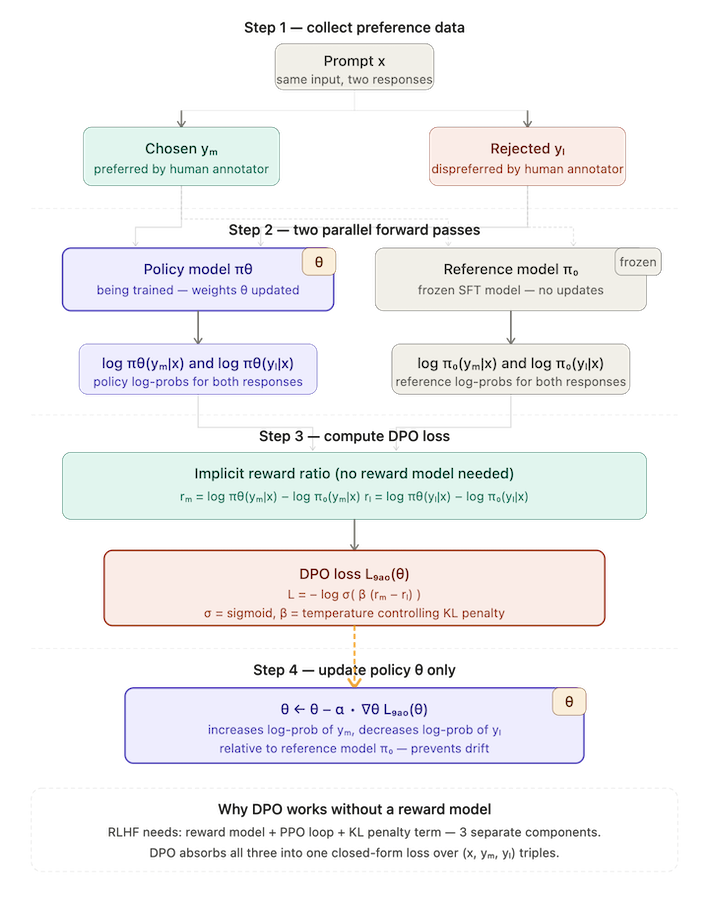

## Idea

DPO stands for **Direct Preference Optimization**. Instead of asking the model to imitate a single gold answer, DPO asks the model to rank a **preferred answer** above a **rejected answer**.

This is useful when there are many acceptable outputs but some are clearly better than others. In the rare-species task, we may prefer answers that:

- name the species correctly,
- report the family and genus,
- state uncertainty when appropriate,
- avoid unjustified certainty.

## Preference data

For each prompt-image pair $(x, v)$ we construct:

- a chosen response $y_w$,
- a rejected response $y_l$.

Here:

- $x$ is the prompt,
- $v$ is the image,
- $y_w$ is the preferred answer,
- $y_l$ is the rejected answer,
- $\pi_\theta$ is the trainable policy,
- $\pi_{\mathrm{ref}}$ is the frozen reference policy,
- $\beta$ controls the sharpness of the preference update.

The chosen answer does not need to be the unique correct answer. It only needs to be better than the rejected one.

## DPO loss

A standard DPO loss is

$$
\mathcal{L}_{\mathrm{DPO}}(\theta)
=
-
\log
\sigma
\left(
\beta
\left[
\log \pi_\theta(y_w \mid x, v)
-
\log \pi_\theta(y_l \mid x, v)
-
\log \pi_{\mathrm{ref}}(y_w \mid x, v)
+
\log \pi_{\mathrm{ref}}(y_l \mid x, v)
\right]
\right).
$$

If we define the preference margin

$$
m
=
\beta
\left[
\log \pi_\theta(y_w \mid x, v)
-
\log \pi_\theta(y_l \mid x, v)
-
\log \pi_{\mathrm{ref}}(y_w \mid x, v)
+
\log \pi_{\mathrm{ref}}(y_l \mid x, v)
\right],
$$

then

$$
\mathcal{L}_{\mathrm{DPO}}(\theta) = - \log \sigma(m).
$$

## Intuition behind the loss

The quantity

$$
\log \pi_\theta(y_w \mid x, v) - \log \pi_\theta(y_l \mid x, v)
$$

asks:

> how much more does the current policy like the winner than the loser?

The reference term

$$
\log \pi_{\mathrm{ref}}(y_w \mid x, v) - \log \pi_{\mathrm{ref}}(y_l \mid x, v)
$$

asks the same question for the frozen reference model.

So DPO is really comparing two margins:

- the policy's current preference margin,
- the reference model's old preference margin.

If the policy does not improve enough over the reference, the loss is large. If the policy clearly prefers the chosen answer more strongly than the reference does, the loss becomes small.

## Why the sigmoid appears

The sigmoid converts the margin into a smooth binary-comparison probability. The resulting loss behaves like logistic regression on pairwise preferences.

So DPO says:

- make the chosen answer score higher,
- make the rejected answer score lower,
- but keep that change measured relative to the reference model.

## Why is DPO often easier than full RLHF?

DPO avoids:

- explicit reward-model fitting during the policy update,
- sampling rollouts during training,
- advantage estimation,
- PPO clipping logic.

It converts preference learning into a stable supervised-style optimization problem over pairs of outputs.

## Code Summary

The code below constructs preferred and rejected species-identification answers, formats them as a conversational vision dataset, and trains the same Qwen VLM with the DPO objective.

## Issues

- DPO needs meaningful **preference pairs**.
- If the **chosen** and **rejected** answers are too easy to separate, the learned preference can be shallow.
- DPO does not directly explore new outputs during training the way online RL does.
- Preference datasets can silently encode **stylistic biases**.

## References

- Rafailov, R., Sharma, A., Mitchell, E., et al.  
  [*Direct Preference Optimization: Your Language Model is Secretly a Reward Model*](https://arxiv.org/abs/2305.18290)

- Azar, M. G., Guo, Z. D., Piot, B., et al.  
  [*A General Theoretical Paradigm to Understand Learning from Human Preferences*](https://arxiv.org/abs/2310.12036)

- Amirloo, E., Fauconnier, J.-P., Roesmann, C., et al.  
  [*Understanding Alignment in Multimodal LLMs: A Comprehensive Study*](https://openreview.net/forum?id=49qqV4NTdy)

- Jiang, S., Zhang, Y., Chen, R., et al.  
  [*Modality-Fair Preference Optimization for Trustworthy MLLM Alignment*](https://www.ijcai.org/proceedings/2025/46)

# DPO vs. KTO 

KTO is another alternative to DPO and is sometimes easier to implement. 

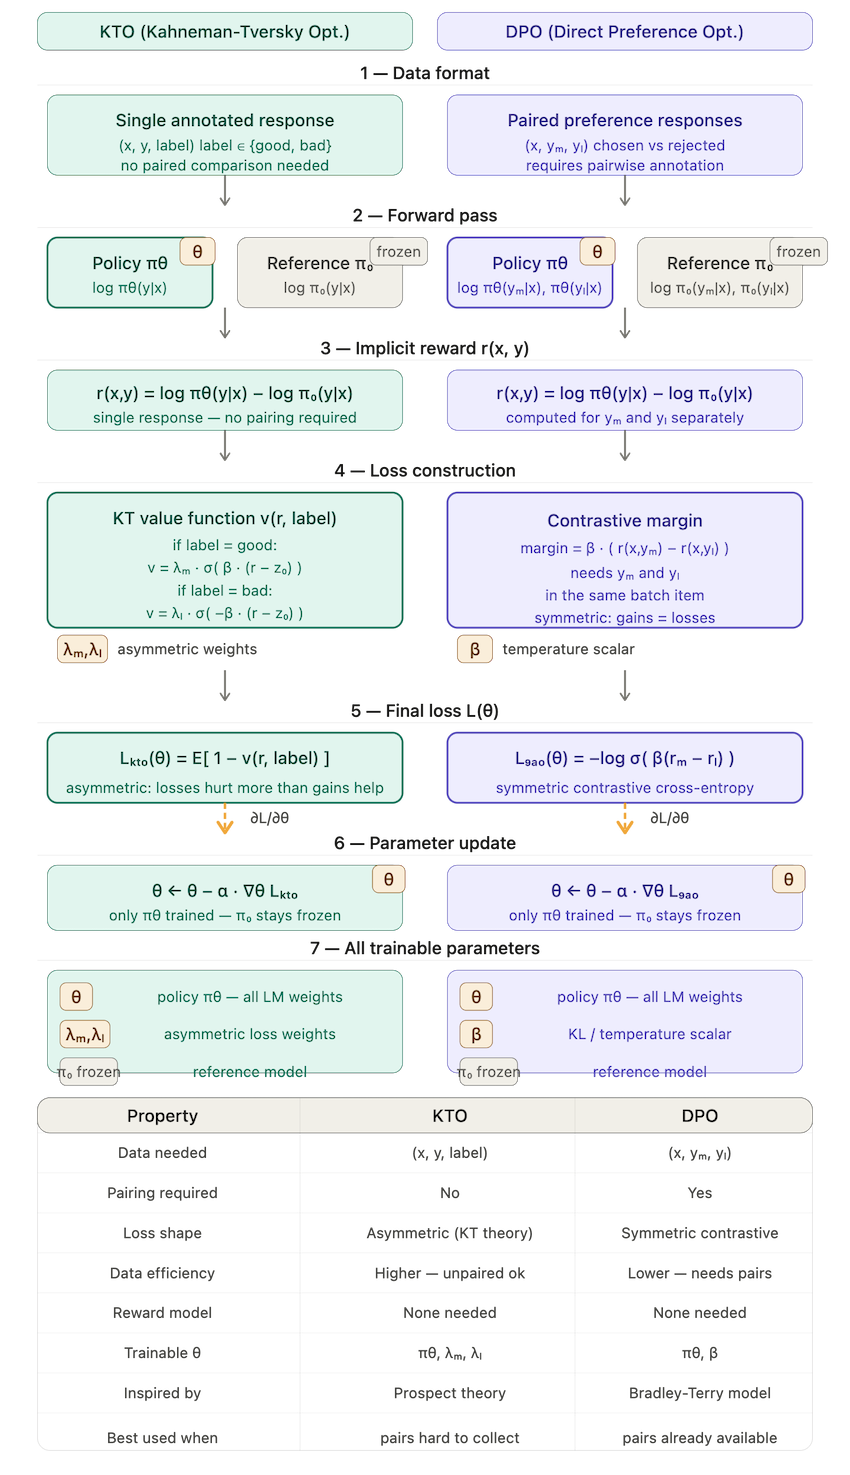

In [ ]:

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

logp_theta_chosen = -1.2
logp_theta_rejected = -2.0
logp_ref_chosen = -1.4
logp_ref_rejected = -1.7
beta = 0.1

margin = beta * (
    (logp_theta_chosen - logp_theta_rejected)
    - (logp_ref_chosen - logp_ref_rejected)
)
dpo_loss = -np.log(sigmoid(margin))

print("margin =", margin)
print("DPO loss =", dpo_loss)


## Build a preference dataset from the rare-species task

The next code cell constructs preference pairs from the same underlying rare-species examples. A single labeled example can support several views:

- an SFT target,
- a chosen response,
- a rejected response,
- multiple preference pairs with different error patterns.

This is one reason alignment data design matters so much: the supervision signal depends not only on what is correct, but also on what kinds of failure we want the model to avoid.


In [ ]:
from datasets import Dataset

def make_bad_answer(example, candidate_species):
    distractors = [c for c in candidate_species if c != example["sciName"]]
    wrong_species = random.choice(distractors)
    return (
        f"scientific_name: {wrong_species}\n"
        f"common_name: unknown\n"
        f"family: unknown\n"
        f"genus: unknown\n"
        f"confidence: 0.99\n"
        f"evidence: This species is definitely correct."
    )

def make_preference_dataset(source_ds, candidate_species):
    rows = []
    for ex in source_ds:
        rows.append(
            {
                "images": [ex["image"]],   # keep image only here
                "prompt": [
                    {"role": "system", "content": SYSTEM_PROMPT},
                    {"role": "user", "content": make_user_prompt(candidate_species)},
                ],
                "chosen": [
                    {"role": "assistant", "content": format_gold_answer(ex)}
                ],
                "rejected": [
                    {"role": "assistant", "content": make_bad_answer(ex, candidate_species)}
                ],
                "sciName": ex["sciName"],
            }
        )
    return Dataset.from_list(rows)

In [ ]:
from transformers import AutoProcessor

# Initialize the processor with specific pixel dimensions for DPO training
min_pixels = 256 * 28 * 28
max_pixels = 1280 * 28 * 28

# dpo_processor will be used to preprocess the images and text for the DPO training phase, ensuring that the 
# input data is appropriately formatted and resized according to the specified pixel constraints. 
# This helps manage memory usage and ensures that the model receives inputs of a consistent size during training.

dpo_processor = AutoProcessor.from_pretrained(
    cfg.model_name,
    min_pixels=min_pixels,
    max_pixels=max_pixels,
)

In [ ]:
from trl import DPOConfig

dpo_args = DPOConfig(
    output_dir=dpo_output_dir,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,
    num_train_epochs=1,
    learning_rate=5e-5,
    logging_steps=10,
    save_strategy="epoch",
    eval_strategy="epoch",
    bf16=True,
    remove_unused_columns=False,
    max_length=None,           # safest first test
    truncation_mode="keep_start", # for classification tasks we want to keep the start of the prompt which contains the 
    # system instructions and candidate species list, and truncate from the end if needed
)

In [ ]:
# The DPOTrainer from TRL will handle the training loop for direct preference optimization, using the "chosen" and "rejected" responses
# to compute the DPO loss and update the model accordingly. This allows us to directly optimize the 
# model's preferences for the correct classifications over the incorrect ones, which can lead to improved performance on

if cfg.run_dpo_training:
    # For DPO training, we load the base model again and prepare it for k-bit training, which is necessary if we are using 4-bit quantization.
    dpo_model, _ = load_qwen_vl(cfg.model_name, use_4bit=cfg.use_4bit)
    
    # Setting use_cache to False is important for training because it prevents the model from caching past key/value states 
    # during generation, which can interfere with gradient computation and backpropagation when we are generating both 
    # "chosen" and "rejected" outputs for DPO.
    dpo_model.config.use_cache = False

    # prepare_model_for_kbit_training will modify the model in-place to make it compatible with k-bit training, which includes
    # adding necessary hooks and adjustments for the quantized weights. This is a crucial step to
    # ensure that the training process can properly compute gradients and update the LoRA adapters when using a quantized model.

    dpo_model = prepare_model_for_kbit_training(dpo_model)

    dpo_trainer = DPOTrainer(
        model=dpo_model,
        ref_model=None,
        args=dpo_args,
        train_dataset=dpo_train_ds,
        eval_dataset=dpo_val_ds,
        processing_class=dpo_processor,
        peft_config=lora_config,
    )

    # train and save the DPO-trained model and processor to the specified output directory. 
    # After training, we can load this adapted model for evaluation on the test set to see if 
    # the DPO training has further improved the model's performance compared to the SFT-trained version.
    dpo_trainer.train()
    dpo_trainer.save_model(dpo_output_dir)
    dpo_processor.save_pretrained(dpo_output_dir)

## DPO training code

The next cells define a practical DPO setup using TRL. DPO can be combined with PEFT adapters, so preference optimization does not necessarily require a full-model update.

Conceptually, we are taking the species-identification policy learned so far and nudging it so that better calibrated, better grounded biodiversity answers become relatively more probable.


In [ ]:
dpo_model_loaded, dpo_processor_loaded = None, None
if os.path.exists(dpo_output_dir):
    dpo_model_loaded, dpo_processor_loaded = load_base_plus_adapter(cfg.model_name, dpo_output_dir, use_4bit=cfg.use_4bit)
    print("Loaded DPO-adapted model.")
else:
    print("DPO adapter directory not found yet. Train first if you want to evaluate this stage.")

# This function generates a prediction for a given example using the DPO-trained model and processor. 
# It constructs the messages for the query example, and then calls the generate_with_explicit_model function 
# with the DPO-adapted model and processor to get the output text.
def generate_with_dpo_policy(example):
    if dpo_model_loaded is None or dpo_processor_loaded is None:
        return ""
    messages = make_single_query_messages(example, candidate_species)
    return generate_with_explicit_model(dpo_model_loaded, dpo_processor_loaded, messages)

# If the DPO model was successfully loaded, we evaluate its accuracy on the test set using the same evaluation function as before,
# which will use the generate_with_dpo_policy function to make predictions with the DPO-adapted model. 
# This allows us to compare the DPO-trained model's performance against the zero-shot
# few-shot, and SFT-trained versions to see if the direct preference optimization has led to further improvements in accuracy.

if dpo_model_loaded is not None:
    dpo_acc, dpo_details = evaluate_method(
        test_ds,
        generate_with_dpo_policy,
        candidate_species,
        limit=min(8, cfg.eval_examples),
    )
    print("DPO accuracy:", round(dpo_acc, 4))
    display(dpo_details.head())

## Issues

### Preference quality is everything

If the chosen and rejected answers are poorly constructed, DPO will optimize the wrong behavior.

### Relative preference is not the same as factual truth

A model can learn to prefer nicer-looking answers unless the preference data explicitly reward correctness and grounding.

### Reference-policy anchoring matters

The reference model prevents the policy from drifting too far, but if the reference is weak, the anchor may also be weak.

## Key references for DPO

- [Rafailov et al., *Direct Preference Optimization: Your Language Model is Secretly a Reward Model* (2023)](https://arxiv.org/abs/2305.18290)
- [Ouyang et al., *Training Language Models to Follow Instructions with Human Feedback* (2022)](https://arxiv.org/abs/2203.02155)
- [TRL DPOTrainer documentation](https://huggingface.co/docs/trl/en/dpo_trainer)


# Method Reinforcement learning from feedback: reward modeling + online RL

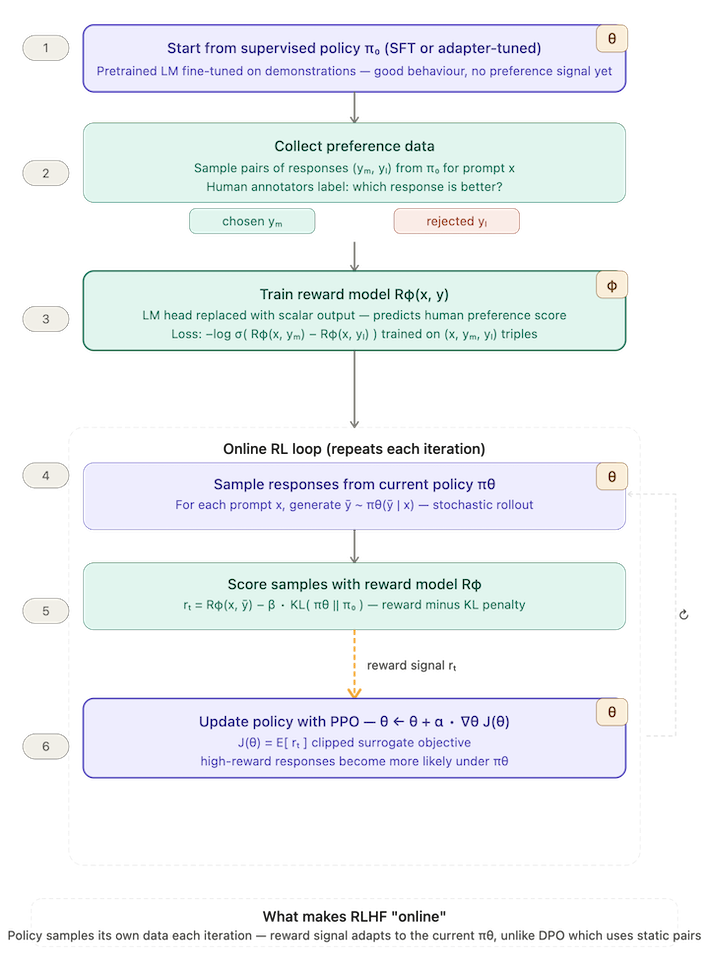

## Idea

This final stage adds **online policy optimization**. The general RLHF recipe is:

1. start from a supervised or adapter-tuned policy,
2. collect or construct preference data,
3. fit a reward model or define a reward function,
4. sample answers from the current policy,
5. give those answers rewards,
6. update the policy so high-reward answers become more likely.

For a VLM, this means the model sees an image and a prompt, generates a candidate answer, receives a scalar reward, and then shifts its token probabilities toward higher-reward behaviors.

## What is fully implemented below?

This notebook now includes two runnable parts:

### Reward modeling

We train a small reward model on the same rare-species preference pairs. This is the classical "fit a scalar judge from pairwise feedback" part of RLHF.

### Online RL on the VLM policy

We then run online reinforcement learning directly on the Qwen VLM using **RLOO**. RLOO is an officially documented online RL trainer for VLMs in TRL. It plays the same conceptual role as PPO-style policy optimization in RLHF: generate, score, regularize, update.

So:

- the **math** still explains the classical PPO picture,
- the **runnable VLM code** uses the online RL path that is currently best supported for VLMs.

## Reward-model objective

A reward model $r_\phi(x, y)$ or $r_\phi(x, v, y)$ maps a prompt and answer to a scalar score.

Given a preferred answer $y_w$ and a rejected answer $y_l$, a standard pairwise loss is

$$
\mathcal{L}_{\mathrm{RM}}(\phi)
=
-
\log
\sigma
\left(
r_\phi(x, v, y_w) - r_\phi(x, v, y_l)
\right).
$$

Here:

- $\phi$ are the reward-model parameters,
- $x$ is the textual prompt,
- $v$ is the image,
- $y_w$ is the preferred answer,
- $y_l$ is the rejected answer,
- $r_\phi(\cdot)$ is the scalar reward produced by the reward model.

Intuition:

- if the reward model already gives the winner a much higher score than the loser, the loss is small,
- if it prefers the loser or is uncertain, the loss is large.

## KL-regularized policy objective

Once a reward signal exists, the policy objective is conceptually

$$
\max_\theta
\;
\mathbb{E}_{y \sim \pi_\theta(\cdot \mid x, v)}
\left[
r(x, v, y)
\right]
-
\beta
\,
\mathrm{KL}
\left(
\pi_\theta(\cdot \mid x, v)
\;\|\;
\pi_{\mathrm{ref}}(\cdot \mid x, v)
\right).
$$

Here:

- $\pi_\theta$ is the current policy,
- $\pi_{\mathrm{ref}}$ is a frozen reference policy,
- $r(x,v,y)$ is either a learned reward model score or a handcrafted/verifiable reward,
- $\beta$ controls how strongly we penalize drift away from the reference model.

The KL term matters because reward hacking is otherwise easy. The model may exploit blind spots in the reward function instead of becoming genuinely better.

## PPO-style intuition

PPO uses the ratio

$$
r_t(\theta)
=
\frac{\pi_\theta(a_t \mid s_t)}
{\pi_{\theta_{\mathrm{old}}}(a_t \mid s_t)},
$$

and the clipped surrogate

$$
L^{\mathrm{CLIP}}(\theta)
=
\mathbb{E}
\left[
\min\left(
r_t(\theta)\hat{A}_t,
\mathrm{clip}(r_t(\theta), 1-\epsilon, 1+\epsilon)\hat{A}_t
\right)
\right].
$$

Here:

- $a_t$ is the generated token at step $t$,
- $s_t$ is the state consisting of image, prompt, and generated prefix,
- $\theta_{\mathrm{old}}$ are the parameters that generated the rollout,
- $\hat{A}_t$ is the advantage estimate,
- $\epsilon$ is the clipping radius.

The intuition is:

- if a sampled action led to higher-than-expected reward, increase its probability,
- but do not increase it too aggressively in a single update.

## Why we are using RLOO for the runnable VLM stage

TRL's documentation explicitly supports VLM training with **RLOO** and lists `Qwen/Qwen2.5-VL-3B-Instruct` among the tested models. That makes RLOO the most direct fully runnable online RL option for the same VLM used throughout this notebook.

So the section below implements:

- a reward-model stage,
- an online RL stage on the VLM policy,
- and a post-training evaluation stage.

## Code walkthrough

The next cells do the following:

1. build a text-only reward-model dataset from the rare-species preference pairs,
2. train a small reward model with `RewardTrainer`,
3. build a conversational VLM RL dataset,
4. define reward functions for format, taxonomic correctness, and calibration,
5. run RLOO on the same Qwen VLM,
6. reload the adapted policy and evaluate it.

## Issues

- Online RL is slower and more brittle than SFT or DPO.
- Reward design matters enormously.
- If the reward is badly specified, the model may learn pathological strategies.
- Classical PPO is possible, but for VLMs the better-supported practical path today is often RLOO or Online DPO rather than raw PPOTrainer code.

## References

- Ouyang, L., Wu, J., Jiang, X., et al.  
  [*Training Language Models to Follow Instructions with Human Feedback*](https://arxiv.org/abs/2203.02155)

- Schulman, J., Wolski, F., Dhariwal, P., Radford, A., Klimov, O.  
  [*Proximal Policy Optimization Algorithms*](https://arxiv.org/abs/1707.06347)

- Ahmadian, A., Cremer, C., Gallé, M., et al.  
  [*Back to Basics: Revisiting REINFORCE-Style Optimization for Learning from Human Feedback in LLMs*](https://arxiv.org/abs/2402.14740)

- Hugging Face TRL documentation.  
  [*Reward Modeling*](https://huggingface.co/docs/trl/reward_trainer)

- Hugging Face TRL documentation.  
  [*RLOO Trainer*](https://huggingface.co/docs/trl/rloo_trainer)

- Hugging Face blog.  
  [*Vision Language Model Alignment in TRL*](https://huggingface.co/blog/trl-vlm-alignment)

- Zhou, Y., Wu, T., Zhang, M., et al.  
  [*Calibrated Self-Rewarding Vision Language Models*](https://proceedings.neurips.cc/paper_files/paper/2024/hash/5c20c00504e0c049ec2370d0cceaf3c4-Abstract-Conference.html)

- Xu, Y., Chen, Y., He, T., et al.  
  [*Adaptive Hallucination Alleviation in Multimodal Large Language Models: From Strategic Data Selection to Severity-Guided Training*](https://ojs.aaai.org/index.php/AAAI/article/view/39955)

- Li, Z., Kong, C., Yu, Y.  
  [*SAVER: Mitigating Hallucinations in Large Vision-Language Models via Style-Aware Visual Early Revision*](https://ojs.aaai.org/index.php/AAAI/article/view/40873)

## RLOO: idea and core math

**RLOO** stands for **REINFORCE Leave-One-Out**. It is an **RL-based alignment method** in which the model generates several candidate completions for the **same prompt**, each completion receives a reward, and the policy is updated to increase the probability of completions that score better than the others.

### Idea

Suppose we sample the same prompt $q$ and generate $G$ completions:

$$
o_1, o_2, \dots, o_G \sim \pi_\theta(\cdot \mid q),
$$

where:

- $\pi_\theta$ is the current policy model,
- $\theta$ are the trainable parameters,
- $q$ is the prompt,
- $o_i$ is the $i$-th sampled completion.

Each completion receives a reward:

$$
r_i = R(q, o_i),
$$

where:

- $R(q, o_i)$ is the reward assigned to completion $o_i$ for prompt $q$.

The key idea of **leave-one-out** is to compare each completion against the **average reward of the other completions for the same prompt**.

For completion $i$, the baseline is:

$$
b_i = \frac{1}{G-1} \sum_{j \neq i} r_j.
$$

Then the advantage for completion $i$ is:

$$
A_i = r_i - b_i.
$$

### Intuition

This means:

- if completion $i$ is **better than the others**, then $A_i > 0$,
- if completion $i$ is **worse than the others**, then $A_i < 0$.

So RLOO asks:

> relative to the other answers generated for the same prompt, was this answer unusually good or unusually bad?

That is why it is called **leave-one-out**: for each completion, we leave that completion out when computing the baseline.

### Policy-gradient view

RLOO is based on a REINFORCE-style policy-gradient update. A simplified objective is:

$$
\mathcal{L}_{\text{RLOO}}(\theta)
=
- \frac{1}{G} \sum_{i=1}^{G} A_i \log \pi_\theta(o_i \mid q).
$$

Here:

- $\mathcal{L}_{\text{RLOO}}(\theta)$ is the training loss,
- $A_i$ is the leave-one-out advantage,
- $\log \pi_\theta(o_i \mid q)$ is the log-probability the model assigns to completion $o_i$.

### Interpretation of the loss

This loss has a very natural meaning:

- if $A_i > 0$, then the model is encouraged to **increase** the probability of $o_i$,
- if $A_i < 0$, then the model is encouraged to **decrease** the probability of $o_i$.

So RLOO pushes the model toward outputs that score higher **relative to other outputs for the same prompt**.

### KL regularization

In practice, RL-based alignment usually adds a penalty that keeps the updated policy close to a reference model $\pi_{\text{ref}}$. A common reward form is:

$$
\tilde{r}_i
=
R(q, o_i)
-
\beta \, \mathrm{KL}\!\left(\pi_\theta \,\|\, \pi_{\text{ref}}\right),
$$

where:

- $\tilde{r}_i$ is the regularized reward,
- $\beta$ controls how strongly we penalize drifting away from the reference model,
- $\pi_{\text{ref}}$ is usually the original pretrained or SFT model.

Then RLOO uses these regularized rewards in place of the raw rewards.

### Why RLOO is useful

RLOO is attractive because:

- it is simpler than heavier RL methods such as PPO,
- it uses a low-variance **relative baseline**,
- and it works naturally when we can score several completions for the same prompt.

### In this example

For our VLM case study, the prompt $q$ may include an **image and a species-identification instruction**, and the reward can be based on things such as:

- whether the scientific name is correct,
- whether the output format is complete,
- whether the explanation is grounded,
- whether the model avoids unjustified overconfidence.

So RLOO can be understood as:

> generate several answers for the same image, score them, compare each answer to the others, and then update the model to make the better answers more likely in the future.

In [ ]:
from trl import RewardConfig, RewardTrainer, RLOOConfig, RLOOTrainer

def serialize_species_prompt(example, candidate_species, include_description=True):
    pieces = [
        "Task: identify the organism in the image from the candidate set.",
        "Candidate species:",
        "\n".join([f"- {c}" for c in candidate_species]),
    ]
    if include_description:
        pieces.append("Image description:")
        pieces.append(describe_image_for_retrieval(example))
    pieces.append("Respond in the structured format used throughout the notebook.")
    return "\n\n".join(pieces)

def make_reward_model_dataset(source_ds, candidate_species, limit=None):
    rows = []
    work_ds = source_ds if limit is None else source_ds.select(range(min(limit, len(source_ds))))
    for ex in work_ds:
        rows.append(
            {
                "prompt": serialize_species_prompt(ex, candidate_species, include_description=True),
                "chosen": format_gold_answer(ex),
                "rejected": make_bad_answer(ex, candidate_species),
                "gold_scientific_name": ex["sciName"],
            }
        )
    return Dataset.from_list(rows)

rm_train_ds = make_reward_model_dataset(train_ds, candidate_species, limit=min(128, len(train_ds)))
rm_val_ds = make_reward_model_dataset(val_ds, candidate_species, limit=min(64, len(val_ds)))

rm_train_ds[0]

In [ ]:
reward_model_name = "Qwen/Qwen2.5-0.5B-Instruct"
reward_model_output_dir = os.path.join(cfg.output_root, "rare_species_reward_model")

reward_args = RewardConfig(
    output_dir=reward_model_output_dir,
    learning_rate=1e-4,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=16,
    num_train_epochs=1,
    logging_steps=5,
    eval_strategy="steps",
    eval_steps=20,
    save_steps=50,
    save_total_limit=2,
    bf16=torch.cuda.is_available(),
    report_to="none",
    max_length=1024,
)

reward_peft_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    task_type="SEQ_CLS",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    modules_to_save=["score"],
)

print(reward_args)
print("Reward model:", reward_model_name)

In [ ]:
# Here we make the rloo dataset, which is similar to the reward model dataset but keeps the image and prompt structure for each example,
# along with the gold labels for later evaluation. This dataset will be used for training the RLOO model,
# which learns to optimize the model's outputs based on the reward signal from the reward

def make_rloo_dataset(source_ds, candidate_species, limit=None):
    rows = []
    work_ds = source_ds if limit is None else source_ds.select(range(min(limit, len(source_ds))))
    for ex in work_ds:
        prompt = [
            {"role": "system", "content": [{"type": "text", "text": SYSTEM_PROMPT}]},
            {
                "role": "user",
                "content": [
                    {"type": "image"},
                    {
                        "type": "text",
                        "text": (
                            "Identify the species in this image from the candidate set below.\n\n"
                            f"{candidate_block(candidate_species)}\n\n"
                            "Return a structured answer with: scientific_name, common_name, family, genus, confidence, evidence."
                        ),
                    },
                ],
            },
        ]
        rows.append(
            {
                "image": ex["image"],
                "prompt": prompt,
                "gold_scientific_name": ex["sciName"],
                "gold_family": ex["family"],
                "gold_genus": ex["genus"],
                "gold_common": ex["common"],
            }
        )
    return Dataset.from_list(rows)

rloo_train_ds = make_rloo_dataset(train_ds, candidate_species, limit=min(96, len(train_ds)))
rloo_val_ds = make_rloo_dataset(val_ds, candidate_species, limit=min(32, len(val_ds)))

rloo_train_ds[0]

In [ ]:
# This function takes the raw completion output from the model, which could be in various formats (string, 
# list of dicts, etc.), and extracts the text content in a consistent way.

def completion_to_text(completion):
    if isinstance(completion, str):
        return completion
    if isinstance(completion, list):
        parts = []
        for item in completion:
            if isinstance(item, dict):
                if "content" in item and isinstance(item["content"], str):
                    parts.append(item["content"])
                elif "content" in item and isinstance(item["content"], list):
                    for sub in item["content"]:
                        if isinstance(sub, dict) and sub.get("type") == "text":
                            parts.append(sub.get("text", ""))
            elif isinstance(item, str):
                parts.append(item)
        return "\n".join([p for p in parts if p])
    return str(completion)

def extract_field(text, field_name):
    pattern = rf"(?im)^\s*{re.escape(field_name)}\s*:\s*(.+?)\s*$"
    match = re.search(pattern, text)
    return match.group(1).strip() if match else None

def format_reward_func(completions, **kwargs):
    rewards = []
    for completion in completions:
        text = completion_to_text(completion)
        ok = all(extract_field(text, key) is not None for key in ["scientific_name", "family", "genus", "confidence", "evidence"])
        rewards.append(1.0 if ok else -1.0)
    return rewards

def species_accuracy_reward_func(completions, gold_scientific_name, **kwargs):
    rewards = []
    for completion, gold in zip(completions, gold_scientific_name):
        text = completion_to_text(completion)
        pred = extract_field(text, "scientific_name")
        rewards.append(3.0 if pred == gold else -2.0)
    return rewards

def taxonomy_reward_func(completions, gold_family, gold_genus, **kwargs):
    rewards = []
    for completion, fam, gen in zip(completions, gold_family, gold_genus):
        text = completion_to_text(completion)
        pred_fam = extract_field(text, "family")
        pred_gen = extract_field(text, "genus")
        reward = 0.0
        if pred_fam == fam:
            reward += 1.0
        if pred_gen == gen:
            reward += 1.0
        rewards.append(reward - 0.5)
    return rewards

def calibration_reward_func(completions, gold_scientific_name, **kwargs):
    rewards = []
    for completion, gold in zip(completions, gold_scientific_name):
        text = completion_to_text(completion)
        pred = extract_field(text, "scientific_name")
        conf_text = extract_field(text, "confidence")
        try:
            conf = float(conf_text) if conf_text is not None else 0.5
        except Exception:
            conf = 0.5
        conf = max(0.0, min(1.0, conf))
        if pred == gold:
            reward = 1.0 - abs(conf - 0.85)
        else:
            reward = -conf
        rewards.append(float(reward))
    return rewards

In [ ]:

# We can experiment with different reward functions to see how they affect the RLOO training and the resulting model's performance.

rloo_output_dir = os.path.join(cfg.output_root, "qwen_rare_species_rloo")

rloo_args = RLOOConfig(
    output_dir=rloo_output_dir,
    learning_rate=1e-6,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,
    num_train_epochs=1,
    logging_steps=2,
    save_steps=25,
    save_total_limit=2,
    bf16=torch.cuda.is_available(),
    report_to="none",
    remove_unused_columns=False,
    max_completion_length=cfg.rloo_max_completion_length,
    num_generations=cfg.rloo_num_generations,
    temperature=0.8,
    top_p=0.95,
    beta=0.05,
    use_vllm=cfg.use_vllm_for_rl,
    vllm_mode="colocate",
    log_completions=True,
)

# We use a similar LoRA configuration for the RLOO training as we did for the SFT training, targeting the same modules in the model. 
# However, since RLOO is a more complex training procedure that involves generating multiple completions and 
# computing rewards, we might want to adjust the learning rate and other training hyperparameters to ensure stable

rloo_peft_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
)

print(rloo_args)

In [ ]:
# Heavy cell: online RL on the VLM policy using RLOO
# Set cfg.run_rloo_training = True to run this stage.

if cfg.run_rloo_training:
    rloo_trainer = RLOOTrainer(
        model=cfg.model_name,
        args=rloo_args,
        train_dataset=rloo_train_ds,
        eval_dataset=rloo_val_ds,
        reward_funcs=[
            format_reward_func,
            species_accuracy_reward_func,
            taxonomy_reward_func,
            calibration_reward_func,
        ],
        peft_config=rloo_peft_config,
    )
    rloo_trainer.train()
    rloo_trainer.save_model(rloo_output_dir)

In [ ]:
    rloo_trainer = RLOOTrainer(
        model=cfg.model_name,
        args=rloo_args,
        train_dataset=rloo_train_ds,
        eval_dataset=rloo_val_ds,
        reward_funcs=[
            format_reward_func,
            species_accuracy_reward_func,
            taxonomy_reward_func,
            calibration_reward_func,
        ],
        peft_config=rloo_peft_config,
    )
    rloo_trainer.train()
    rloo_trainer.save_model(rloo_output_dir)

In [ ]:
rloo_model, rloo_processor = None, None
if os.path.exists(rloo_output_dir):
    rloo_model, rloo_processor = load_base_plus_adapter(cfg.model_name, rloo_output_dir, use_4bit=cfg.use_4bit)
    print("Loaded RLOO-adapted policy.")
else:
    print("RLOO adapter directory not found yet. Train first if you want to evaluate this stage.")

def generate_with_rloo_policy(example):
    if rloo_model is None or rloo_processor is None:
        return ""
    messages = make_single_query_messages(example, candidate_species)
    return generate_with_explicit_model(rloo_model, rloo_processor, messages)

if rloo_model is not None:
    rloo_acc, rloo_details = evaluate_method(
        test_ds,
        generate_with_rloo_policy,
        candidate_species,
        limit=min(8, cfg.eval_examples),
    )
    print("RLOO accuracy:", round(rloo_acc, 4))
    display(rloo_details.head())

# Revisit the method table: empirical and conceptual comparison

This section returns to the original method table and summarizes the methods on the same task.


In [ ]:
summary_rows = [
    {"method": "Zero-shot", "changes_weights": False, "needs_examples": False, "needs_retriever": False, "accuracy": zero_shot_acc},
    {"method": "Few-shot", "changes_weights": False, "needs_examples": True,  "needs_retriever": False, "accuracy": few_shot_acc},
    {"method": "RAG",       "changes_weights": False, "needs_examples": False, "needs_retriever": True,  "accuracy": rag_acc},
]

if "lora_acc" in globals():
    summary_rows.append({"method": "LoRA / QLoRA SFT", "changes_weights": True, "needs_examples": True, "needs_retriever": False, "accuracy": lora_acc})

if "dpo_acc" in globals():
    summary_rows.append({"method": "DPO", "changes_weights": True, "needs_examples": True, "needs_retriever": False, "accuracy": dpo_acc})

if "rloo_acc" in globals():
    summary_rows.append({"method": "Online RL (RLOO)", "changes_weights": True, "needs_examples": True, "needs_retriever": False, "accuracy": rloo_acc})

summary_df = pd.DataFrame(summary_rows)
summary_df

## Method-by-method comparison

### Method — Zero-shot
- cheapest,
- fastest,
- best first baseline,
- limited specialization.

### Method — Few-shot
- still no training,
- good for formatting and task steering,
- limited by context length and exemplar quality.

### Method — RAG
- injects external knowledge,
- strong for grounding and provenance,
- does not fundamentally fix weak visual representations.

### Method — SFT
- teaches direct target behavior,
- stronger and more persistent than prompting,
- requires labeled demonstrations.

### Method — LoRA / QLoRA
- captures much of the benefit of tuning at lower memory cost,
- especially attractive on a single strong GPU,
- requires choices about target modules and rank.

### Method — DPO
- optimizes relative preferences rather than only demonstrations,
- bridges supervised tuning and RLHF,
- useful when better-vs-worse judgments are easier to obtain than perfect targets.

### Method — RLHF / PPO /RLOO
- most expressive and most complex,
- closest to online reward optimization,
- highest engineering and evaluation burden.


## Fine-tuning case study summary table

**Case study:** `Qwen2.5-VL-3B-Instruct` on **Rare Species**, using reduced image resolution through Qwen's `min_pixels` / `max_pixels` controls.

These are **rough engineering estimates**, not official benchmarks. They assume:
- one single device,
- moderate image-token limits,
- a 3B VLM,
- and a practical lecture/lab style workflow rather than highly optimized distributed training.

| Method | Extra labeled data needed | A100 80GB | RTX 5090 32GB | DGX Spark | Practical recommendation |
|---|---:|---:|---:|---:|---|
| Zero-shot | 0 | Minutes | Minutes | Minutes | Always do first |
| Few-shot | 3–16 exemplars in prompt | Minutes | Minutes | Minutes | Best cheap upgrade over zero-shot |
| RAG | 0 labeled; ~400–1200 species cards/passages | <1 hour setup/indexing | <1 hour setup/indexing | <1 hour setup/indexing | Best when you want grounded explanations |
| Full SFT | ~5k–20k examples | ~8–24 GPU-hours | ~12–36 GPU-hours | ~1–3+ days | Best raw adaptation, but highest supervised cost |
| LoRA | ~1k–10k examples | ~2–8 GPU-hours | ~3–12 GPU-hours | ~8–24 hours | Best first true fine-tuning method |
| QLoRA | ~1k–10k examples | ~3–10 GPU-hours | ~4–14 GPU-hours | ~10–30 hours | Best memory-efficient fine-tuning path |
| DPO | ~5k–20k chosen/rejected pairs | ~4–12 GPU-hours | ~6–18 GPU-hours | ~12–36 hours | Best post-SFT alignment step |
| RLOO / RL-based | ~1k–5k prompts, multiple rollouts each | ~10–50+ GPU-hours | ~15–80+ GPU-hours | Small demo scale only | Use as the capstone, not the first training method |

# References

Below is a compact list of the most important references behind the notebook. All links are clickable.

## Core methods

1. **LoRA**  
   Hu, E. J., Shen, Y., Wallis, P., et al.  
   [*LoRA: Low-Rank Adaptation of Large Language Models*](https://arxiv.org/abs/2106.09685)

2. **QLoRA**  
   Dettmers, T., Pagnoni, A., Holtzman, A., Zettlemoyer, L.  
   [*QLoRA: Efficient Finetuning of Quantized LLMs*](https://arxiv.org/abs/2305.14314)

3. **RAG**  
   Lewis, P., Perez, E., Piktus, A., et al.  
   [*Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks*](https://arxiv.org/abs/2005.11401)

4. **Dense retrieval**  
   Karpukhin, V., Oguz, B., Min, S., et al.  
   [*Dense Passage Retrieval for Open-Domain Question Answering*](https://arxiv.org/abs/2004.04906)

5. **DPO**  
   Rafailov, R., Sharma, A., Mitchell, E., et al.  
   [*Direct Preference Optimization: Your Language Model is Secretly a Reward Model*](https://arxiv.org/abs/2305.18290)

6. **RLHF / InstructGPT**  
   Ouyang, L., Wu, J., Jiang, X., et al.  
   [*Training Language Models to Follow Instructions with Human Feedback*](https://arxiv.org/abs/2203.02155)

7. **RLOO**  
   Ahmadian, A., Cremer, C., Gallé, M., et al.  
   [*Back to Basics: Revisiting REINFORCE-Style Optimization for Learning from Human Feedback in LLMs*](https://arxiv.org/abs/2402.14740)

8. **PPO**  
   Schulman, J., Wolski, F., Dhariwal, P., Radford, A., Klimov, O.  
   [*Proximal Policy Optimization Algorithms*](https://arxiv.org/abs/1707.06347)

9. **Policy gradient foundations**  
   Sutton, R. S., McAllester, D., Singh, S., Mansour, Y.  
   [*Policy Gradient Methods for Reinforcement Learning with Function Approximation*](https://papers.nips.cc/paper/1713-policy-gradient-methods-for-reinforcement-learning-with-function-approximation)

10. **Few-shot prompting / in-context learning**  
    Brown, T. B., Mann, B., Ryder, N., et al.  
    [*Language Models are Few-Shot Learners*](https://arxiv.org/abs/2005.14165)

11. **In-context learning analysis**  
    Min, S., Lyu, X., Holtzman, A., et al.  
    [*Rethinking the Role of Demonstrations: What Makes In-Context Learning Work?*](https://arxiv.org/abs/2202.12837)

12. **Implicit Bayesian view of in-context learning**  
    Xie, S. M., Raghunathan, A., Liang, P., Ma, T.  
    [*An Explanation of In-context Learning as Implicit Bayesian Inference*](https://arxiv.org/abs/2111.02080)

## Dataset and biodiversity context

13. **Rare Species dataset card**  
    [*imageomics/rare-species*](https://huggingface.co/datasets/imageomics/rare-species)

14. **BioCLIP**  
    Stevens, S., Wu, J., Thompson, M. J., et al.  
    [*BioCLIP: A Vision Foundation Model for the Tree of Life*](https://arxiv.org/abs/2311.18803)

## Practical tooling

15. **Qwen2.5-VL model card**  
    [*Qwen/Qwen2.5-VL-3B-Instruct*](https://huggingface.co/Qwen/Qwen2.5-VL-3B-Instruct)

16. **Transformers tokenizer documentation**  
    [*apply_chat_template and assistant-token masks*](https://huggingface.co/docs/transformers/main_classes/tokenizer)

17. **Transformers multimodal chat templates**  
    [Hugging Face Transformers documentation](https://huggingface.co/docs/transformers/en/chat_templating_multimodal)

18. **PEFT LoRA documentation**  
    [Hugging Face PEFT documentation](https://huggingface.co/docs/peft/en/package_reference/lora)

19. **TRL SFTTrainer documentation**  
    [Hugging Face TRL SFTTrainer documentation](https://huggingface.co/docs/trl/en/sft_trainer)

20. **TRL DPOTrainer documentation**  
    [Hugging Face TRL DPOTrainer documentation](https://huggingface.co/docs/trl/dpo_trainer)

21. **TRL RewardTrainer documentation**  
    [Hugging Face TRL Reward Modeling documentation](https://huggingface.co/docs/trl/reward_trainer)

22. **TRL RLOOTrainer documentation**  
    [Hugging Face TRL RLOOTrainer documentation](https://huggingface.co/docs/trl/rloo_trainer)

23. **TRL VLM alignment blog**  
    [*Vision Language Model Alignment in TRL*](https://huggingface.co/blog/trl-vlm-alignment)

24. **Qwen assistant-mask discussion**  
    [*Chat template of AutoTokenizer does not work on assistant mask tokens*](https://huggingface.co/Qwen/Qwen2.5-VL-3B-Instruct/discussions/27)

## Recent 2024–2026 papers from major venues

25. **ICLR 2025 — theory for token-level RAG**  
    Xu, S., Pang, L., Shen, H., Cheng, X.  
    [*A Theory for Token-Level Harmonization in Retrieval-Augmented Generation*](https://openreview.net/forum?id=tbx3u2oZAu)

26. **ICLR 2025 — hybrid / faithful RAG**  
    Ma, S., Xu, C., Jiang, X., et al.  
    [*Think-on-Graph 2.0: Deep and Faithful Large Language Model Reasoning with Knowledge-guided Retrieval-Augmented Generation*](https://openreview.net/forum?id=oFBu7qaZpS)

27. **ICLR 2025 — multimodal alignment study**  
    Amirloo, E., Fauconnier, J.-P., Roesmann, C., et al.  
    [*Understanding Alignment in Multimodal LLMs: A Comprehensive Study*](https://openreview.net/forum?id=49qqV4NTdy)

28. **NeurIPS 2024 — self-rewarding VLM alignment**  
    Zhou, Y., Wu, T., Zhang, M., et al.  
    [*Calibrated Self-Rewarding Vision Language Models*](https://proceedings.neurips.cc/paper_files/paper/2024/hash/5c20c00504e0c049ec2370d0cceaf3c4-Abstract-Conference.html)

29. **NeurIPS 2024 — multi-objective multimodal alignment**  
    Yang, K., Gao, Y., Wang, H., et al.  
    [*MetaAligner: Towards Generalizable Multi-Objective Alignment of Vision-Language Models*](https://proceedings.neurips.cc/paper_files/paper/2024/file/3d03800841fa1bb2f43ef1750aafcce4-Paper-Conference.pdf)

30. **NeurIPS 2024 — self-training for VLMs**  
    Deng, Y., Zhang, X., Xu, Y., et al.  
    [*Enhancing Large Vision Language Models with Self-Training on Image Comprehension*](https://proceedings.neurips.cc/paper_files/paper/2024/file/ed45d6a03de84cc650cae0655f699356-Paper-Conference.pdf)

31. **AAAI 2026 — multimodal hallucination alleviation**  
    Xu, Y., Chen, Y., He, T., et al.  
    [*Adaptive Hallucination Alleviation in Multimodal Large Language Models: From Strategic Data Selection to Severity-Guided Training*](https://ojs.aaai.org/index.php/AAAI/article/view/39955)

32. **AAAI 2026 — hallucination mitigation via early revision**  
    Li, Z., Kong, C., Yu, Y.  
    [*SAVER: Mitigating Hallucinations in Large Vision-Language Models via Style-Aware Visual Early Revision*](https://ojs.aaai.org/index.php/AAAI/article/view/40873)

33. **AAAI 2026 — human preference learning in vision generation**  
    Xu, J., Huang, Y., Cheng, J., et al.  
    [*VisionReward: Fine-Grained Multi-Dimensional Human Preference Learning for Image and Video Generation*](https://ojs.aaai.org/index.php/AAAI/article/view/38107)

34. **IJCAI 2025 — survey on visual underuse in MLLMs**  
    Jain, A., Vatsa, M., Singh, R.  
    [*Words Over Pixels? Rethinking Vision in Multimodal Large Language Models*](https://www.ijcai.org/proceedings/2025/1164)

35. **IJCAI 2025 — prompt learning for VLM adaptation**  
    Lv, S.-L., Chen, Y.-Y., Zhou, Z., Yang, M., Guo, L.-Z.  
    [*BMIP: Bi-directional Modality Interaction Prompt Learning for VLM*](https://www.ijcai.org/proceedings/2025/655)

36. **IJCAI 2025 — preference optimization for trustworthy MLLMs**  
    Jiang, S., Zhang, Y., Chen, R., et al.  
    [*Modality-Fair Preference Optimization for Trustworthy MLLM Alignment*](https://www.ijcai.org/proceedings/2025/46)

## Note on IJCAI 2026

As of the date of this notebook, the IJCAI-ECAI 2026 conference website is public, but the 2026 proceedings are not yet public. That is why the newest IJCAI papers cited here are from 2025.

- [IJCAI-ECAI 2026 conference site](https://2026.ijcai.org/)

## Use of Generative AI

Portions of this material were developed with the assistance of **generative artificial intelligence tools.  
The author reviewed, edited, and validated all content, including explanations, code, and examples, and assumes full responsibility for accuracy and interpretation.